In [1]:
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.12.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Name: NVIDIA RTX 4000 Ada Generation


In [2]:
# ============================================================
# Step 1 — Environment, Imports, Reproducibility, and Runtime Setup
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes
# Optimization Mode: VRAM-Armored Mixed Precision Fine-Tuning
# ============================================================

import os
import cv2
import gc
import math
import glob
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Strict CUDA memory behavior to prevent fragmentation on 16GB/24GB VRAM
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Schedulers & Data Loading
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader

# VRAM Optimization Tools (AMP & Checkpointing)
from torch.amp import GradScaler, autocast
from torch.utils.checkpoint import checkpoint 

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm
from sklearn.metrics import confusion_matrix

from transformers import Mask2FormerConfig, Mask2FormerForUniversalSegmentation

# --------------------------------------------------
# Cleanup and warning control
# --------------------------------------------------
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

warnings.filterwarnings("ignore", category=UserWarning)

# --------------------------------------------------
# Reproducibility Setup
# --------------------------------------------------
SEED = 42

def set_seed(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        try:
            torch.use_deterministic_algorithms(True)
        except Exception:
            pass
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

set_seed(SEED, deterministic=False)
print(f"Seed set to {SEED} (deterministic=False for stable/efficient training)")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# --------------------------------------------------
# Matplotlib & Seaborn Styling Setup
# --------------------------------------------------
%matplotlib inline
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 600
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.9)

# --------------------------------------------------
# Device & Engine Configuration
# --------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Toolchain Version: {torch.version.cuda}")
    print(f"Total Available GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

if torch.cuda.is_available():
    try:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        print("TF32 matrix operations enabled successfully.")
    except Exception as e:
        print(f"TF32 configuration skipped: {e}")

# --------------------------------------------------
# AMP Setup
# --------------------------------------------------
USE_AMP = torch.cuda.is_available()
scaler = GradScaler("cuda" if torch.cuda.is_available() else "cpu", enabled=USE_AMP)
print(f"Mixed Precision Training Enabled: {USE_AMP}")

# --------------------------------------------------
# CENTRALIZED DIRECTORY & PATH MAPPING
# --------------------------------------------------
# 1. Dataset Roots (Using expanduser() to properly resolve '~' in Ubuntu)
IMG_ROOT = Path("~/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit").expanduser()
MASK_ROOT = Path("~/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine").expanduser()

# 2. Final Export & Visualization Targets
FINAL_SAVE_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export").expanduser()
QUAL_VIS_DIR = Path("~/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/training_visuals").expanduser()

# 3. Local Working Directories (Updated for PMA naming convention)

CHECKPOINT_DIR = FINAL_SAVE_DIR / "progressive_checkpoints_pma_cs_AB3"
PLOTS_DIR = FINAL_SAVE_DIR / "training_plots_pma_cs_AB3"
LOGS_DIR = FINAL_SAVE_DIR / "training_logs_pma_cs_AB3"
METRICS_DIR = FINAL_SAVE_DIR/ "training_metrics_pma_cs_AB3"

# Safely build all target directories
for d in [CHECKPOINT_DIR, PLOTS_DIR, LOGS_DIR, METRICS_DIR, FINAL_SAVE_DIR, QUAL_VIS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Model Specifications
# --------------------------------------------------
MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
MODEL_ALIAS = "Mask2Former + Probabilistic Masked Attention (PMA)"

print(f"\nModel Configuration Linked: {MODEL_ALIAS}")
print(f"Pre-trained Model Base: {MODEL_NAME}")
print(f"Global Analytical Results Save Path Linked: {FINAL_SAVE_DIR.resolve()}")

# --------------------------------------------------
# Runtime Performance Containers
# --------------------------------------------------
history = {
    "epoch": [],
    "phase": [],
    # Training Loop Loss Tracking
    "train_total_loss": [],
    "train_native_loss": [],
    "train_ce_loss": [],
    "train_lovasz_loss": [],
    "train_boundary_loss": [], 
    "train_miou": [],    
    "train_macc": [],    
    "train_aacc": [],    
    # Validation Evaluation Metrics
    "val_total_loss": [],
    "val_ce_loss": [],
    "val_miou": [],
    "val_macc": [],
    "val_aacc": [],
    # Optimizer State & Module Dynamics Records
    "pma_tau": [],  # Tracking our continuous masking temperature parameter
    "epoch_time_sec": []
}

best_record = {
    "epoch": -1,
    "best_epoch": -1,
    "best_miou": -1.0,
    "best_macc": -1.0,
    "best_aacc": -1.0,
    "best_path": str(CHECKPOINT_DIR / "best_miou_pma_checkpoint_AB3.pt")
}

print("Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.")

/home/ubuntu/miniconda3/envs/foggy/lib/python3.13/site-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: Hostname mismatch, certificate is not valid for 'pypi.org'. (_ssl.c:1032)>
  data = fetch_version_info()


Seed set to 42 (deterministic=False for stable/efficient training)
Using Device: cuda
GPU Model: NVIDIA RTX 4000 Ada Generation
CUDA Toolchain Version: 12.6
Total Available GPU Memory: 19.67 GB
TF32 matrix operations enabled successfully.
Mixed Precision Training Enabled: True

Model Configuration Linked: Mask2Former + Probabilistic Masked Attention (PMA)
Pre-trained Model Base: facebook/mask2former-swin-small-cityscapes-semantic
Global Analytical Results Save Path Linked: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export
Metrics tracking layers constructed. Global paths centralized. Step 1 initialization sequence completed.


In [3]:
# ============================================================
# STEP 2: HYPERPARAMETERS, LABEL ENCODING, VISUALIZATION
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes (Continuous Multi-Rate Configuration)
# ============================================================

from pathlib import Path
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn.functional as F

# Note: Paths (IMG_ROOT, MASK_ROOT, FINAL_SAVE_DIR, QUAL_VIS_DIR) 
# and DEVICE are globally inherited from Step 1.

print(f"Image root inherited: {IMG_ROOT}")
print(f"Mask root inherited : {MASK_ROOT}")
print(f"Visualizations target: {QUAL_VIS_DIR.resolve()}")
print(f"Final export target: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# CORE TASK SETTINGS (Cityscapes 19-Class Standard)
# ------------------------------------------------------------
CLASSES = 19
IGNORE_INDEX = 255
USE_LABEL_TRAINIDS = True

CLASS_NAMES = [
    "Road", "Sidewalk", "Building", "Wall", "Fence", "Pole",
    "Traffic Light", "Traffic Sign", "Vegetation", "Terrain", "Sky",
    "Person", "Rider", "Car", "Truck", "Bus", "Train", "Motorcycle", "Bicycle"
]

# Standard Cityscapes RGB Color Palette
CITYSCAPES_PALETTE = np.array([
    [128, 64, 128],   # Road
    [244, 35, 232],   # Sidewalk
    [70, 70, 70],     # Building
    [102, 102, 156],  # Wall
    [190, 153, 153],  # Fence
    [153, 153, 153],  # Pole
    [250, 170, 30],   # Traffic Light
    [220, 220, 0],    # Traffic Sign
    [107, 142, 35],   # Vegetation
    [152, 251, 152],  # Terrain
    [70, 130, 180],   # Sky
    [220, 20, 60],    # Person
    [255, 0, 0],      # Rider
    [0, 0, 142],      # Car
    [0, 0, 70],       # Truck
    [0, 60, 100],     # Bus
    [0, 80, 100],     # Train
    [0, 0, 230],      # Motorcycle
    [119, 11, 32]     # Bicycle
], dtype=np.uint8)

# ------------------------------------------------------------
# IMAGE GEOMETRY (Optimized for PMA + Multi-Scale Augmentation)
# ------------------------------------------------------------
# Training utilizes square crops for positional embedding stability
TRAIN_CROP_SIZE = (768, 768) 

# Validation uses sliding window on native aspect ratio
VAL_IMG_H = 512
VAL_IMG_W = 1024

# ------------------------------------------------------------
# BATCHING AND EPOCHS (Hardware Optimized for RTX A4000 16GB)
# ------------------------------------------------------------
# CRITICAL: Do not increase BATCH_SIZE. Continuous masking (PMA) 
# requires active gradient tracking across all soft-masked pixels.
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 4    # Effective batch size = 8
EPOCHS = 120
USE_EARLY_STOPPING = False  

# ------------------------------------------------------------
# PMA-MASK2FORMER OPTIMIZATION SCHEDULE
# ------------------------------------------------------------
# Unified learning rate for the entire architecture (No multi-rate)
GLOBAL_LR = 5e-5
BASE_HEAD_LR = GLOBAL_LR
BACKBONE_LR = GLOBAL_LR

# Progressive Unfreezing Schedule
FREEZE_BACKBONE_EPOCHS = 10 # Swin stays frozen while PMA head initializes
WARMUP_EPOCHS = 0          # Initial linear LR warmup

# APMA (Annealed Probabilistic Masked Attention) Parameters
APMA_INITIAL_TAU = 1.0    # Starts highly continuous (soft)
APMA_MIN_TAU = 0.05       # Hardens boundaries by final epochs

WEIGHT_DECAY = 0.01
GRAD_CLIP_NORM = 1.0      # Mandatory for continuous modules to prevent explosions
FREEZE_BATCHNORM_STATS = True  

print("\n--- PMA-Mask2Former Multi-Rate Fine-Tuning Schedule ---")
print(f"Total Training Epochs  : {EPOCHS}")
print(f"Backbone Frozen Epochs : {FREEZE_BACKBONE_EPOCHS} Epochs")
print(f"Linear Warmup Period   : {WARMUP_EPOCHS} Epochs")
print(f"Decoder Head LR        : {BASE_HEAD_LR}")
print(f"Swin Backbone LR       : {BACKBONE_LR}")
print(f"PMA Mask Temperature   : \u03c4 decays from {APMA_INITIAL_TAU} to {APMA_MIN_TAU}")

# ------------------------------------------------------------
# SCHEDULER / LOSS SETTINGS
# ------------------------------------------------------------
USE_FOCAL_LOSS = True   
FOCAL_GAMMA = 2.0
FOCAL_WEIGHT = 1.0

USE_LOVASZ = True
LOVASZ_WEIGHT = 0.5

USE_BOUNDARY_LOSS = True
BOUNDARY_LOSS_WEIGHT = 0.25

print("\n--- Loss Formulation ---")
print(f"Focal Loss Enabled    : {USE_FOCAL_LOSS} (Gamma={FOCAL_GAMMA}, Weight={FOCAL_WEIGHT})")
print(f"Lovasz Enabled        : {USE_LOVASZ} (Weight={LOVASZ_WEIGHT})")
print(f"Boundary Loss Enabled : {USE_BOUNDARY_LOSS} (Weight={BOUNDARY_LOSS_WEIGHT})")

# ------------------------------------------------------------
# VALIDATION / INFERENCE SETTINGS
# ------------------------------------------------------------
USE_SLIDING_WINDOW_VAL = True 
VAL_WINDOW_SIZE = (512, 1024)
VAL_WINDOW_STRIDE = (512, 512)   
USE_FLIP_TTA = True

# ------------------------------------------------------------
# 34 -> 19 LABEL MAPPING & ENCODING (Cityscapes Specific)
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    uniq = np.unique(mask)
    if uniq.max() <= 255 and np.all(np.isin(uniq, list(range(CLASSES)) + [IGNORE_INDEX])):
        return mask.astype(np.uint8)
    encoded = LABEL_LUT[mask.clip(0, 255)]
    return encoded.astype(np.uint8)

def decode_segmap(segmentation_map: np.ndarray) -> np.ndarray:
    h, w = segmentation_map.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    valid_mask = (segmentation_map >= 0) & (segmentation_map < CLASSES)
    for label, color in enumerate(CITYSCAPES_PALETTE):
        rgb[segmentation_map == label] = color
    rgb[~valid_mask] = np.array([0, 0, 0], dtype=np.uint8)
    return rgb

# ------------------------------------------------------------
# PUBLICATION-READY EVALUATION CURVES
# ------------------------------------------------------------
def plot_training_curves(history_dict, save_path):
    """
    Plots Total Loss and mIoU curves dynamically and saves them to disk.
    Identifies the transition point where the warm-up phase ends.
    """
    epochs = history_dict["epoch"]
    if len(epochs) == 0: return

    sns.set_theme(style="darkgrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Total Loss Curve
    axes[0].plot(epochs, history_dict["train_total_loss"], label='Train Total Loss', color='blue', linewidth=2)
    if len(history_dict["val_total_loss"]) == len(epochs):
        axes[0].plot(epochs, history_dict["val_total_loss"], label='Validation Loss', color='red', linewidth=2)
    axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    
    if len(epochs) >= WARMUP_EPOCHS:
        axes[0].axvline(x=WARMUP_EPOCHS, color='black', linestyle='--', label='Warmup Concluded')
    axes[0].legend(fontsize=12)

    # Plot 2: mIoU Curve
    if len(history_dict["train_miou"]) == len(epochs):
        axes[1].plot(epochs, history_dict["train_miou"], label='Train mIoU', color='green', linewidth=2)
    if len(history_dict["val_miou"]) == len(epochs):
        axes[1].plot(epochs, history_dict["val_miou"], label='Validation mIoU', color='orange', linewidth=2)
    
    axes[1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('mIoU (%)', fontsize=12)
    
    if len(epochs) >= WARMUP_EPOCHS:
        axes[1].axvline(x=WARMUP_EPOCHS, color='black', linestyle='--', label='Warmup Concluded')
    axes[1].legend(fontsize=12)

    plt.tight_layout()
    plt.savefig(save_path, dpi=600, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# QUALITATIVE VISUALIZATION
# ------------------------------------------------------------
def visualize_results(loader, model, epoch, save_path=QUAL_VIS_DIR, max_images=3):
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    model.eval()

    batch = next(iter(loader))
    images, mask_labels, class_labels = batch
    images = images.to(DEVICE)
    _, _, current_h, current_w = images.shape

    with torch.no_grad():
        with torch.autocast(device_type="cuda", enabled=(torch.cuda.is_available() and images.is_cuda)):
            # Standard Forward Pass 
            outputs = model(pixel_values=images)
            
            mask_preds = F.interpolate(outputs.masks_queries_logits, size=(current_h, current_w), mode="bilinear", align_corners=False)
            mask_cls = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]
            semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds.sigmoid())
            
            preds = torch.argmax(semantic_logits, dim=1).cpu().numpy()

    images_np = images.detach().cpu().numpy()
    targets = np.full((len(images_np), current_h, current_w), IGNORE_INDEX, dtype=np.uint8)

    for batch_idx in range(len(class_labels)):
        for inst_idx, class_id in enumerate(class_labels[batch_idx]):
            cls_id = int(class_id.item())
            if cls_id != IGNORE_INDEX and 0 <= cls_id < CLASSES:
                instance_mask = mask_labels[batch_idx][inst_idx].cpu().numpy() == 1
                targets[batch_idx][instance_mask] = cls_id

    n = min(max_images, len(images_np))
    fig, axes = plt.subplots(n, 3, figsize=(15, 5 * n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i in range(n):
        img = np.transpose(images_np[i], (1, 2, 0))
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title("Input Image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(decode_segmap(targets[i]))
        axes[i, 1].set_title("Ground Truth")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(decode_segmap(preds[i]))
        axes[i, 2].set_title(f"PMA-Mask2Former Pred (Epoch {epoch})")
        axes[i, 2].axis("off")

    plt.tight_layout()
    out_file = save_path / f"epoch_{epoch:03d}_comparison.png"
    plt.savefig(out_file, dpi=600, bbox_inches="tight")
    plt.close(fig)

def save_visuals_every_10_epochs(epoch, loader, model, save_path=QUAL_VIS_DIR, max_images=3):
    if epoch % 10 == 0:
        visualize_results(loader, model, epoch, save_path, max_images)

# ------------------------------------------------------------
# QUICK DATA DISCOVERY
# ------------------------------------------------------------
train_imgs = sorted(list(IMG_ROOT.rglob("*.png")))
train_masks = sorted(list(MASK_ROOT.rglob("*_labelIds.png")))

print(f"Discovered {len(train_imgs)} images and {len(train_masks)} masks.")
print("Step 2 fully configured and optimized for PMA Architecture.")

Image root inherited: /home/ubuntu/miniconda3/envs/foggy/Dataset/leftImg8bit_trainvaltest/leftImg8bit
Mask root inherited : /home/ubuntu/miniconda3/envs/foggy/Dataset/gtFine_trainvaltest/gtFine
Visualizations target: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/training_visuals
Final export target: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export

--- PMA-Mask2Former Multi-Rate Fine-Tuning Schedule ---
Total Training Epochs  : 120
Backbone Frozen Epochs : 10 Epochs
Linear Warmup Period   : 0 Epochs
Decoder Head LR        : 5e-05
Swin Backbone LR       : 5e-05
PMA Mask Temperature   : τ decays from 1.0 to 0.05

--- Loss Formulation ---
Focal Loss Enabled    : True (Gamma=2.0, Weight=1.0)
Lovasz Enabled        : True (Weight=0.5)
Boundary Loss Enabled : True (Weight=0.25)
Discovered 5000 images and 5000 masks.
Step 2 fully configured and optimized for PMA Architecture.


In [4]:
# ============================================================
# STEP 3: DATASET AND DATALOADERS
# Target Architecture: Mask2Former + Probabilistic Masked Attention (PMA)
# Target Dataset: Cityscapes
# Optimized for: Native Train Splits, Rare-Class Synergy, Multi-Scale PMA Crops
# ============================================================

import inspect
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import os
import random

# ------------------------------------------------------------
# DATASET DISCOVERY FOR CITYSCAPES
# ------------------------------------------------------------
# Cityscapes already provides explicit train/val folders, nested by city.
def get_cityscapes_pairs(split):
    img_split_dir = IMG_ROOT / split
    mask_split_dir = MASK_ROOT / split
    
    # Cityscapes images end in _leftImg8bit.png
    all_imgs = sorted(list(img_split_dir.rglob("*_leftImg8bit.png")))
    
    valid_imgs = []
    valid_masks = []
    
    for img_path in all_imgs:
        # e.g., aachen_000000_000019_leftImg8bit.png -> aachen_000000_000019_gtFine_labelIds.png
        mask_name = img_path.name.replace("_leftImg8bit.png", "_gtFine_labelIds.png")
        city_name = img_path.parent.name
        mask_path = mask_split_dir / city_name / mask_name
        
        if mask_path.exists():
            valid_imgs.append(img_path)
            valid_masks.append(mask_path)
            
    return valid_imgs, valid_masks

train_img_paths, train_mask_paths = get_cityscapes_pairs("train")
val_img_paths, val_mask_paths = get_cityscapes_pairs("val")

if len(train_img_paths) == 0 or len(val_img_paths) == 0:
    raise FileNotFoundError("Could not find valid Cityscapes image/mask pairs. Please check paths and directory structures.")

print(f"\n--- Cityscapes Dataset Split ---")
print(f"Training image/mask pairs   : {len(train_img_paths)}")
print(f"Validation image/mask pairs : {len(val_img_paths)}")

# ------------------------------------------------------------
# CITYSCAPES 34 -> 19 CLASS MAPPING
# ------------------------------------------------------------
mapping_34_to_19 = {
    0: 255, 1: 255, 2: 255, 3: 255, 4: 255, 5: 255, 6: 255,
    7: 0, 8: 1, 9: 255, 10: 255, 11: 2, 12: 3, 13: 4,
    14: 255, 15: 255, 16: 255, 17: 5, 18: 255, 19: 6, 20: 7,
    21: 8, 22: 9, 23: 10, 24: 11, 25: 12, 26: 13, 27: 14,
    28: 15, 29: 255, 30: 255, 31: 16, 32: 17, 33: 18, -1: 255
}

LABEL_LUT = np.full(256, IGNORE_INDEX, dtype=np.uint8)
for k, v in mapping_34_to_19.items():
    if 0 <= k <= 255:
        LABEL_LUT[k] = v

def encode_mask(mask: np.ndarray) -> np.ndarray:
    """Fast mapping from 34 IDs to 19 Train IDs."""
    return LABEL_LUT[mask.clip(0, 255)].astype(np.uint8)

# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------
class CityscapesDataset(Dataset):
    def __init__(self, image_paths, mask_paths, split="train", transform=None, rare_class_ids=None, rare_retry_count=0):
        self.transform = transform
        self.split = split
        self.rare_class_ids = rare_class_ids if rare_class_ids is not None else []
        self.rare_retry_count = rare_retry_count
        self.images = image_paths
        self.masks = mask_paths

    def __len__(self):
        return len(self.images)

    def _contains_rare_class(self, mask):
        if len(self.rare_class_ids) == 0: return False
        unique_ids = np.unique(mask)
        return any(cls_id in unique_ids for cls_id in self.rare_class_ids)

    def __getitem__(self, idx):
        img_path = str(self.images[idx])
        mask_path = str(self.masks[idx])

        image = cv2.imread(img_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        mask_raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask_raw is None:
            raise ValueError(f"Failed to read mask: {mask_path}")
            
        mask = encode_mask(mask_raw)

        if self.transform is not None:
            if self.split == "train" and self.rare_retry_count > 0:
                selected_aug = None
                for _ in range(self.rare_retry_count):
                    augmented = self.transform(image=image, mask=mask)
                    aug_mask = augmented["mask"]
                    aug_mask_np = aug_mask.cpu().numpy() if torch.is_tensor(aug_mask) else aug_mask

                    if self._contains_rare_class(aug_mask_np):
                        selected_aug = augmented
                        break
                    selected_aug = augmented
                augmented = selected_aug
            else:
                augmented = self.transform(image=image, mask=mask)

            image = augmented["image"]
            mask = augmented["mask"]

        if not torch.is_tensor(image):
            image = torch.as_tensor(image).permute(2, 0, 1).float()
        if not torch.is_tensor(mask):
            mask = torch.as_tensor(mask, dtype=torch.long)
        else:
            mask = mask.long()

        # Build standard Mask2Former target format (K, H, W)
        unique_labels = torch.unique(mask)
        unique_labels = unique_labels[unique_labels != IGNORE_INDEX]

        if unique_labels.numel() == 0:
            class_labels = torch.empty((0,), dtype=torch.long)
            mask_labels = torch.empty((0, mask.shape[0], mask.shape[1]), dtype=torch.float32)
        else:
            class_labels = unique_labels.long()
            mask_labels = (mask.unsqueeze(0) == class_labels[:, None, None]).float()

        return image, mask_labels, class_labels

# ------------------------------------------------------------
# AUGMENTATION HELPERS & TRANSFORMS
# ------------------------------------------------------------
def pad_if_needed_tf(min_h, min_w, ignore_index=255):
    sig = inspect.signature(A.PadIfNeeded)
    kwargs = dict(min_height=min_h, min_width=min_w, border_mode=cv2.BORDER_CONSTANT, p=1.0)
    if "fill" in sig.parameters:
        kwargs.update(fill=0, fill_mask=ignore_index)
    else:
        kwargs.update(value=0, mask_value=ignore_index)
    return A.PadIfNeeded(**kwargs)

# For Cityscapes (1024x2048), cropping to TRAIN_CROP_SIZE (e.g., 768x768) for training
train_transform = A.Compose([
    A.RandomScale(scale_limit=(-0.5, 1.0), interpolation=cv2.INTER_LINEAR, p=1.0), 
    pad_if_needed_tf(TRAIN_CROP_SIZE[0], TRAIN_CROP_SIZE[1], IGNORE_INDEX),
    A.RandomCrop(height=TRAIN_CROP_SIZE[0], width=TRAIN_CROP_SIZE[1], p=1.0),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.GaussianBlur(blur_limit=(3, 3), p=0.1),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# Validation transform completely bypasses Cropping
val_transform = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(transpose_mask=True),
])

# ------------------------------------------------------------
# COLLATE FUNCTION
# ------------------------------------------------------------
def mask2former_collate_fn(batch):
    images = torch.stack([item[0] for item in batch], dim=0)
    mask_labels = [item[1] for item in batch]
    class_labels = [item[2] for item in batch]
    return images, mask_labels, class_labels

# ------------------------------------------------------------
# INITIALIZATION
# ------------------------------------------------------------
USE_RARE_CLASS_AWARE_SAMPLING = True
# Classes: Wall, Fence, Pole, Traffic Light, Traffic Sign, Rider, Truck, Bus, Train, Motorcycle, Bicycle
RARE_CLASS_IDS = [3, 4, 5, 6, 7, 12, 14, 15, 16, 17, 18]  

rare_retry_count = 8 if USE_RARE_CLASS_AWARE_SAMPLING else 0

train_dataset = CityscapesDataset(
    image_paths=train_img_paths, mask_paths=train_mask_paths, split="train",
    transform=train_transform, rare_class_ids=RARE_CLASS_IDS, rare_retry_count=rare_retry_count
)

val_dataset = CityscapesDataset(
    image_paths=val_img_paths, mask_paths=val_mask_paths, split="val",
    transform=val_transform, rare_class_ids=None, rare_retry_count=0
)

NUM_WORKERS = min(4, os.cpu_count() if os.cpu_count() is not None else 2)
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0

print(f"\n--- DataLoader Hardware Configuration ---")
print(f"Num workers         : {NUM_WORKERS}")
print(f"Pin memory          : {PIN_MEMORY}")
print(f"Rare retry count    : {rare_retry_count}")

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False,
    collate_fn=mask2former_collate_fn,
    worker_init_fn=seed_worker if "seed_worker" in globals() else None,
    generator=g if "g" in globals() else None,
    persistent_workers=PERSISTENT_WORKERS
)

# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------
train_batch = next(iter(train_loader))
train_images, train_mask_labels, train_class_labels = train_batch

print("\n--- Train Batch Sanity Check ---")
print(f"Images shape              : {train_images.shape} (Targeting {TRAIN_CROP_SIZE[0]}x{TRAIN_CROP_SIZE[1]})")
print(f"Sample 0 num segments     : {train_mask_labels[0].shape[0]}")
print(f"Sample 0 mask tensor shape: {train_mask_labels[0].shape}")

val_batch = next(iter(val_loader))
val_images, _, _ = val_batch

assert train_images.shape[-2:] == TRAIN_CROP_SIZE, f"Expected train crop {TRAIN_CROP_SIZE}, got {train_images.shape[-2:]}"

print(f"Validation images shape   : {val_images.shape} (Native Cityscapes Resolution)")
print("\nStep 3 configured successfully and ready to feed the PMA-Mask2Former model.")


--- Cityscapes Dataset Split ---
Training image/mask pairs   : 2975
Validation image/mask pairs : 500

--- DataLoader Hardware Configuration ---
Num workers         : 4
Pin memory          : True
Rare retry count    : 8

--- Train Batch Sanity Check ---
Images shape              : torch.Size([2, 3, 768, 768]) (Targeting 768x768)
Sample 0 num segments     : 11
Sample 0 mask tensor shape: torch.Size([11, 768, 768])
Validation images shape   : torch.Size([1, 3, 1024, 2048]) (Native Cityscapes Resolution)

Step 3 configured successfully and ready to feed the PMA-Mask2Former model.


In [5]:
# ============================================================
# STEP 4: MODEL, PMA INJECTION, LOSS, MULTI-RATE SCHEDULER
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION (SINGLE CONSTANT LR - AB3)
# ============================================================

import os
import math
import types
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR, LambdaLR
from transformers import Mask2FormerForUniversalSegmentation

# ------------------------------------------------------------
# LOAD PRETRAINED BASE MODEL (Swin-Small + Mask2Former)
# ------------------------------------------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASSES = 19
IGNORE_INDEX = 255
EPOCHS = 120
FREEZE_BACKBONE_EPOCHS = 10

MODEL_NAME = "facebook/mask2former-swin-small-cityscapes-semantic"
model = Mask2FormerForUniversalSegmentation.from_pretrained(
    MODEL_NAME, 
    ignore_mismatched_sizes=True, 
    num_labels=CLASSES
).to(DEVICE)

print(f"Loaded Base Model: {MODEL_NAME}")

# ------------------------------------------------------------
# NOVEL ARCHITECTURAL INJECTION: PROBABILISTIC MASKED ATTENTION (PMA)
# ------------------------------------------------------------
class PMAManager:
    """Manages the continuous temperature relaxation for Mask2Former Attention."""
    def __init__(self, initial_tau=1.0, min_tau=0.05, total_epochs=120):
        self.tau = initial_tau
        self.min_tau = min_tau
        self.decay_rate = (min_tau / initial_tau) ** (1.0 / total_epochs)

    def step_epoch(self):
        self.tau = max(self.min_tau, self.tau * self.decay_rate)
        
    def apply_pma(self, mask_logits):
        """
        The Core PMA Mathematical Formulation:
        M_{l-1}(x,y) = tau * log(sigmoid(M_hat_{l-1}(x,y) / tau))
        """
        if mask_logits is None or not torch.is_tensor(mask_logits):
            return mask_logits
            
        scaled_logits = mask_logits / self.tau
        probs = torch.sigmoid(scaled_logits)
        
        bias = self.tau * torch.log(probs + 1e-6)
        return torch.clamp(bias, min=-50.0, max=0.0)

# Instantiate the global PMA Manager
pma_manager = PMAManager(initial_tau=1.0, min_tau=0.05, total_epochs=EPOCHS)

def inject_pma_into_mask2former(model, manager):
    transformer_decoder = model.model.transformer_module.decoder

    for layer in transformer_decoder.layers:
        original_layer_forward = layer.forward
        
        def pma_layer_forward(self, *args, **kwargs):
            if 'attention_mask' in kwargs and kwargs['attention_mask'] is not None:
                kwargs['attention_mask'] = manager.apply_pma(kwargs['attention_mask'])
            return original_layer_forward(*args, **kwargs)

        layer.forward = types.MethodType(pma_layer_forward, layer)

    print("Probabilistic Masked Attention (PMA) successfully injected into Decoder Layers.")

# Apply the injection
inject_pma_into_mask2former(model, pma_manager)

# Target VRAM Optimization
if hasattr(model.model.pixel_level_module.encoder, "gradient_checkpointing"):
    model.model.pixel_level_module.encoder.gradient_checkpointing = True

# ------------------------------------------------------------
# HYBRID LOSS FORMULATION
# ------------------------------------------------------------
CITYSCAPES_WEIGHTS = torch.tensor([
    2.5, 4.0, 3.0, 7.5, 7.0, 6.0, 6.5, 5.5, 3.2, 4.5, 3.5, 5.0, 6.5, 3.0, 8.5, 8.5, 9.0, 7.5, 6.0
], dtype=torch.float32).to(DEVICE)

def compute_soft_boundary_map(semantic_logits: torch.Tensor) -> torch.Tensor:
    probs = F.softmax(semantic_logits.float(), dim=1)
    B, C, H, W = probs.shape
    boundary = torch.zeros((B, 1, H, W), device=probs.device, dtype=probs.dtype)
    dh = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1]).mean(dim=1, keepdim=True)
    boundary[:, :, :, 1:] += dh
    dv = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :]).mean(dim=1, keepdim=True)
    boundary[:, :, 1:, :] += dv
    return boundary.clamp(min=0.0, max=1.0)

def compute_boundary_loss(semantic_logits, dense_targets):
    with torch.no_grad():
        target_boundary = torch.zeros_like(dense_targets, dtype=torch.bool)
        valid = (dense_targets != IGNORE_INDEX)
        target_boundary[:, 1:] |= ((dense_targets[:, 1:] != dense_targets[:, :-1]) & valid[:, 1:] & valid[:, :-1])
        target_boundary[:, :, 1:] |= ((dense_targets[:, :, 1:] != dense_targets[:, :, :-1]) & valid[:, :, 1:] & valid[:, :, :-1])
        target_boundary = target_boundary.unsqueeze(1).float()
        
    pred_boundary = compute_soft_boundary_map(semantic_logits)
    return F.smooth_l1_loss(pred_boundary, target_boundary)

def compute_hybrid_loss(outputs, dense_targets):
    native_loss = outputs.loss if outputs.loss is not None else torch.tensor(0.0, device=DEVICE)
    
    H, W = dense_targets.shape[1], dense_targets.shape[2]
    mask_preds_up = F.interpolate(outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(outputs.class_queries_logits, dim=-1)[..., :-1]
    
    semantic_logits = torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())
    
    ce_loss = F.cross_entropy(semantic_logits, dense_targets, weight=CITYSCAPES_WEIGHTS, ignore_index=IGNORE_INDEX)
    boundary_loss = compute_boundary_loss(semantic_logits, dense_targets)
    
    total_loss = native_loss + ce_loss + (0.25 * boundary_loss)
    return total_loss

# ------------------------------------------------------------
# PROGRESSIVE OPTIMIZER (ABLATION: SINGLE CONSTANT LR - AB3)
# ------------------------------------------------------------
backbone_params, head_params = [], []

for n, p in model.named_parameters():
    p.requires_grad = True
    if "base_model" in n and "pixel_level_module.encoder.encoder" in n:
        if FREEZE_BACKBONE_EPOCHS > 0:
            p.requires_grad = False
        else:
            backbone_params.append(p)
    else:
        head_params.append(p)

# === ABLATION MODIFICATION: SINGLE CONSTANT LEARNING RATE ===
GLOBAL_LR = 5e-5  # Unified learning rate for the entire architecture
BASE_HEAD_LR = GLOBAL_LR
BACKBONE_LR = GLOBAL_LR
print(f"\n[*] Ablation Active: SINGLE CONSTANT LR set to {GLOBAL_LR}")
print(f"[*] (No Multi-Rate Head/Backbone split, No Cosine/Linear Scheduler)")
# =====================================================

param_groups = [{"params": head_params, "lr": BASE_HEAD_LR}]
if len(backbone_params) > 0: 
    param_groups.append({"params": backbone_params, "lr": BACKBONE_LR})

optimizer = optim.AdamW(param_groups, weight_decay=0.01, betas=(0.9, 0.999), eps=1e-8)

def unfreeze_swin_backbone(model, optimizer):
    print(f"\n[Progressive Unfreezing] Integrating Swin Backbone at unified LR={BACKBONE_LR}...")
    b_params = []
    for n, p in model.named_parameters():
        if "base_model" in n and "pixel_level_module.encoder.encoder" in n:
            p.requires_grad = True
            b_params.append(p)
    optimizer.add_param_group({"params": b_params, "lr": BACKBONE_LR})
    print("Backbone unfreezing complete.")

# === ABLATION MODIFICATION: FLAT SCHEDULER ===
# A LambdaLR that always returns 1.0 keeps the learning rate perfectly flat
scheduler = LambdaLR(optimizer, lr_lambda=lambda epoch: 1.0)

print("Optimization pipeline ready. CONSTANT LR scheduling initialized.")

Loading weights:   0%|          | 0/758 [00:00<?, ?it/s]

[transformers] Mask2FormerForUniversalSegmentation LOAD REPORT from: facebook/mask2former-swin-small-cityscapes-semantic
Key                                                                                                                      | Status     | 
-------------------------------------------------------------------------------------------------------------------------+------------+-
model.pixel_level_module.encoder.swin.encoder.layers.{0, 1, 2, 3}.blocks.{0...17}.attention.self.relative_position_index | UNEXPECTED | 
model.pixel_level_module.encoder.swin.layernorm.bias                                                                     | MISSING    | 
model.pixel_level_module.encoder.swin.layernorm.weight                                                                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the c

Loaded Base Model: facebook/mask2former-swin-small-cityscapes-semantic
Probabilistic Masked Attention (PMA) successfully injected into Decoder Layers.

[*] Ablation Active: SINGLE CONSTANT LR set to 5e-05
[*] (No Multi-Rate Head/Backbone split, No Cosine/Linear Scheduler)
Optimization pipeline ready. CONSTANT LR scheduling initialized.


In [6]:
# ============================================================
# STEP 5: TRAINING LOOP (ULTIMATE PYTORCH 2.5+ HOTFIX)
# Target Architecture: Swin-Small + Mask2Former + PMA
# Optimization Mode: ABLATION (SINGLE CONSTANT LR - AB3)
# ============================================================

import os
import gc
import math
import time
from datetime import timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
from tqdm import tqdm

# ------------------------------------------------------------
# SAFETY CHECKS & ABLATION PATH INHERITANCE
# ------------------------------------------------------------
DEVICE = globals().get("DEVICE", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
USE_AMP = torch.cuda.is_available()
CLASSES = globals().get("CLASSES", 19)
IGNORE_INDEX = globals().get("IGNORE_INDEX", 255)
EPOCHS = globals().get("EPOCHS", 120)
FREEZE_BACKBONE_EPOCHS = globals().get("FREEZE_BACKBONE_EPOCHS", 10)
GRAD_CLIP_NORM = 1.0
MIN_DELTA_MIOU = 0.001

# Safely inherit the AB3 Checkpoint directory you defined in Step 1/2/3
CHECKPOINT_DIR = globals().get("CHECKPOINT_DIR", Path("./progressive_checkpoints_pma_cs_AB3"))
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
QUAL_VIS_DIR = globals().get("QUAL_VIS_DIR", Path("./training_visuals"))

scaler = GradScaler("cuda", enabled=USE_AMP)

# ------------------------------------------------------------
# SEMANTIC TARGETS & METRICS HELPERS
# ------------------------------------------------------------
def get_semantic_logits(model_outputs, image_size):
    H, W = image_size
    mask_preds_up = F.interpolate(model_outputs.masks_queries_logits, size=(H, W), mode="bilinear", align_corners=False)
    mask_cls = F.softmax(model_outputs.class_queries_logits, dim=-1)[..., :-1]
    return torch.einsum("bqc,bqhw->bchw", mask_cls, mask_preds_up.sigmoid())

def build_semantic_targets(mask_labels, class_labels, image_size, ignore_index=255):
    H, W = image_size
    batch_size = len(mask_labels)
    device = mask_labels[0].device if len(mask_labels) > 0 else DEVICE
    targets = torch.full((batch_size, H, W), fill_value=ignore_index, dtype=torch.long, device=device)
    for b in range(batch_size):
        if class_labels[b].numel() == 0: continue
        for inst_idx, cls_id in enumerate(class_labels[b]):
            cls_id = int(cls_id.item())
            if cls_id == ignore_index: continue
            targets[b][mask_labels[b][inst_idx] > 0.5] = cls_id
    return targets

def compute_metrics(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc), "iou_per_class": iou_per_class, "acc_per_class": acc_per_class}

def fast_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, num_classes: int) -> np.ndarray:
    idx = num_classes * y_true + y_pred
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)

def get_lr_snapshot(optimizer):
    lrs = [pg["lr"] for pg in optimizer.param_groups]
    if len(lrs) == 1: return 0.0, lrs[0]
    return lrs[1], lrs[0]

def multi_scale_tta_inference(model, image, scales=[0.75, 1.0, 1.25], num_classes=19):
    B, C, H, W = image.shape
    final_logits = torch.zeros((B, num_classes, H, W), device=image.device, dtype=torch.float32)
    for scale in scales:
        sH, sW = int(H * scale), int(W * scale)
        sH, sW = (sH // 32) * 32, (sW // 32) * 32 
        scaled_img = F.interpolate(image, size=(sH, sW), mode='bilinear', align_corners=False)
        with torch.no_grad():
            with autocast("cuda", enabled=False):
                outputs = model(pixel_values=scaled_img)
                final_logits += get_semantic_logits(outputs, (H, W)).float()
        flipped_img = torch.flip(scaled_img, dims=[3])
        with torch.no_grad():
            with autocast("cuda", enabled=False):
                outputs = model(pixel_values=flipped_img)
                final_logits += torch.flip(get_semantic_logits(outputs, (H, W)), dims=[3]).float()
    return final_logits / (len(scales) * 2)

# ------------------------------------------------------------
# CRASH RECOVERY PROTOCOL
# ------------------------------------------------------------
start_epoch = 1
global_update_step = 0
best_conf_matrix = None
best_metrics = None
training_start_time = time.time()
cumulative_training_time_sec = 0.0 
current_phase = "PMA-Mask2Former Unified Training"

latest_ckpt_path = os.path.join(CHECKPOINT_DIR, "latest_checkpoint_AB3.pt")

if os.path.exists(latest_ckpt_path):
    print(f"\n[*] CRASH RECOVERY TRIGGERED: Found checkpoint at {latest_ckpt_path}")
    try:
        checkpoint = torch.load(latest_ckpt_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        
        start_epoch = checkpoint['epoch'] + 1
        global_update_step = checkpoint['global_update_step']
        best_record = checkpoint['best_record']
        history = checkpoint['history']
        cumulative_training_time_sec = checkpoint.get('cumulative_training_time_sec', 0.0)
        
        for _ in range(start_epoch - 1):
            pma_manager.step_epoch()
            
        expected_len = len(optimizer.param_groups)
        for attr_name in ['schedulers', '_schedulers']:
            if hasattr(scheduler, attr_name):
                for sub_sched in getattr(scheduler, attr_name):
                    if hasattr(sub_sched, 'base_lrs'):
                        while len(sub_sched.base_lrs) < expected_len:
                            sub_sched.base_lrs.append(globals().get("GLOBAL_LR", 5e-5))
        if hasattr(scheduler, 'base_lrs'):
            while len(scheduler.base_lrs) < expected_len:
                scheduler.base_lrs.append(globals().get("GLOBAL_LR", 5e-5))
        print("[*] Applied Constant LR Scheduler Hotfix for final epoch.")
        print(f"[*] Successfully restored state. Resuming training from Epoch {start_epoch}.")
    except Exception as e:
        print(f"[!] Warning: Failed to load checkpoint cleanly: {e}")
        history = globals().get("history", {})
else:
    print(f"No checkpoint found in {CHECKPOINT_DIR}. Starting fresh.")
    history = globals().get("history", {})

# === THE KEYERROR FAILSAFE ===
# Guarantees all required lists exist in the history dictionary before we start appending
required_history_keys = [
    "epoch", "phase", "train_total_loss", "val_total_loss", "val_ce_loss",
    "train_miou", "val_miou", "val_macc", "val_aacc",
    "backbone_lr", "head_lr", "epoch_time_sec", "pma_tau"
]
for k in required_history_keys:
    if k not in history:
        history[k] = []
# =============================

GRAD_ACCUM_STEPS = globals().get("GRAD_ACCUM_STEPS", 4)
print(f"\n--- Launching PMA-Mask2Former Single-Rate Pipeline (AB3) ---")
print(f"Target Epochs: {EPOCHS} (Currently at {start_epoch})")

# ------------------------------------------------------------
# MAIN TRAINING LOOP
# ------------------------------------------------------------
for epoch in range(start_epoch, EPOCHS + 1):
    epoch_start_time = time.time()
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    model.train()
    optimizer.zero_grad(set_to_none=True)

    train_total_loss_sum = 0.0
    train_batches = 0
    train_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    train_pbar = tqdm(train_loader, total=len(train_loader), desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False)

    for step, (images, mask_labels, class_labels) in enumerate(train_pbar, start=1):
        images = images.to(DEVICE, non_blocking=True)
        target_list = []
        for i in range(len(class_labels)):
            if len(class_labels[i]) > 0:
                target_list.append({"masks": mask_labels[i].to(DEVICE, non_blocking=True), "labels": class_labels[i].to(DEVICE, non_blocking=True)})
            else:
                target_list.append({"masks": torch.empty((0, images.shape[2], images.shape[3]), device=DEVICE), "labels": torch.empty((0,), dtype=torch.long, device=DEVICE)})

        _, _, curr_h, curr_w = images.shape
        dense_targets = build_semantic_targets([t["masks"] for t in target_list], [t["labels"] for t in target_list], (curr_h, curr_w), IGNORE_INDEX)

        with autocast("cuda", enabled=(USE_AMP and images.is_cuda)):
            outputs = model(pixel_values=images, mask_labels=[t["masks"] for t in target_list], class_labels=[t["labels"] for t in target_list])
            total_loss = compute_hybrid_loss(outputs, dense_targets)
            loss = total_loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        train_total_loss_sum += total_loss.detach().item()
        train_batches += 1

        with torch.no_grad():
            semantic_logits = get_semantic_logits(outputs, (curr_h, curr_w))
            preds_np = torch.argmax(semantic_logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                train_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)

        if (step % GRAD_ACCUM_STEPS == 0) or (step == len(train_loader)):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            
            try:
                scheduler.step()
            except ValueError as e:
                if "zip" in str(e):
                    for param_group in optimizer.param_groups:
                        param_group['lr'] = globals().get("GLOBAL_LR", 5e-5)
                else:
                    raise e
                    
            global_update_step += 1

        lr_backbone, lr_head = get_lr_snapshot(optimizer)
        train_pbar.set_postfix(loss=f"{train_total_loss_sum / max(1, train_batches):.4f}", lr=f"{lr_head:.2e}")

    train_metrics = compute_metrics(train_conf_matrix)
    train_total_loss = train_total_loss_sum / max(1, train_batches)

    # Validation Mode (WITH TTA)
    model.eval()
    val_ce_loss_sum = 0.0
    val_total_batches = 0
    val_conf_matrix = np.zeros((CLASSES, CLASSES), dtype=np.int64)
    val_pbar = tqdm(val_loader, total=len(val_loader), desc=f"Epoch {epoch}/{EPOCHS} [Val (TTA)]", leave=False)

    with torch.no_grad():
        for images, mask_labels, class_labels in val_pbar:
            images = images.to(DEVICE, non_blocking=True)
            _, _, val_h, val_w = images.shape
            mask_labels = [m.to(DEVICE, non_blocking=True) for m in mask_labels]
            class_labels = [c.to(DEVICE, non_blocking=True) for c in class_labels]
            dense_targets = build_semantic_targets(mask_labels, class_labels, (val_h, val_w), IGNORE_INDEX)

            semantic_logits = multi_scale_tta_inference(model, images, scales=[0.75, 1.0, 1.25], num_classes=CLASSES)

            loss_ce = F.cross_entropy(semantic_logits, dense_targets, weight=CITYSCAPES_WEIGHTS, ignore_index=IGNORE_INDEX)
            val_ce_loss_sum += loss_ce.item()
            val_total_batches += 1

            preds_np = torch.argmax(semantic_logits, dim=1).detach().cpu().numpy().astype(np.int64)
            targets_np = dense_targets.detach().cpu().numpy().astype(np.int64)
            valid = (targets_np != IGNORE_INDEX)
            if valid.any():
                val_conf_matrix += fast_confusion_matrix(targets_np[valid], preds_np[valid], CLASSES)
            val_pbar.set_postfix(mIoU=f"{compute_metrics(val_conf_matrix)['mIoU'] * 100:.2f}%", val_loss=f"{val_ce_loss_sum/val_total_batches:.4f}")

    val_metrics = compute_metrics(val_conf_matrix)
    val_total_loss = val_ce_loss_sum / max(1, val_total_batches)

    current_tau = pma_manager.tau
    pma_manager.step_epoch()

    epoch_time = time.time() - epoch_start_time
    cumulative_training_time_sec += epoch_time  
    lr_backbone, lr_head = get_lr_snapshot(optimizer)

    # ETA Calculation
    avg_epoch_time = cumulative_training_time_sec / epoch
    eta_seconds = avg_epoch_time * (EPOCHS - epoch)
    eta_str = str(timedelta(seconds=int(eta_seconds)))

    # Safely append metrics
    history["epoch"].append(epoch)
    history["phase"].append(current_phase)
    history["train_total_loss"].append(train_total_loss)
    history["val_total_loss"].append(val_total_loss)       
    history["val_ce_loss"].append(val_total_loss)         
    history["train_miou"].append(train_metrics["mIoU"] * 100) 
    history["val_miou"].append(val_metrics["mIoU"] * 100) 
    history["val_macc"].append(val_metrics["mAcc"] * 100) 
    history["val_aacc"].append(val_metrics["aAcc"] * 100) 
    history["backbone_lr"].append(lr_backbone)
    history["head_lr"].append(lr_head)
    history["epoch_time_sec"].append(epoch_time)
    history["pma_tau"].append(current_tau)

    print(
        f"\nEpoch {epoch}/{EPOCHS} | Epoch Time: {epoch_time:.2f}s | ETA: {eta_str} \n"
        f"Train Loss: {train_total_loss:.4f} | Val Loss: {val_total_loss:.4f}\n"
        f"Train mIoU: {train_metrics['mIoU']*100:.2f}% | Val mIoU: {val_metrics['mIoU']*100:.2f}%\n"
        f"LR Backbone: {lr_backbone:.2e} | APMA \u03c4: {current_tau:.4f}"
    )

    if 'save_visuals_every_10_epochs' in globals():
        save_visuals_every_10_epochs(epoch, val_loader, model, QUAL_VIS_DIR)

    ckpt_dict = {
        "epoch": epoch, "global_update_step": global_update_step,
        "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(), "best_record": best_record,
        "history": history, "cumulative_training_time_sec": cumulative_training_time_sec 
    }
    
    torch.save(ckpt_dict, latest_ckpt_path)

    if val_metrics["mIoU"] > (best_record["best_miou"] + MIN_DELTA_MIOU):
        best_record["best_epoch"] = epoch
        best_record["best_miou"] = val_metrics["mIoU"]
        best_record["best_macc"] = val_metrics["mAcc"]
        best_record["best_aacc"] = val_metrics["aAcc"]
        best_conf_matrix = val_conf_matrix.copy()
        best_metrics = val_metrics.copy()
        best_ckpt_path = os.path.join(CHECKPOINT_DIR, "best_miou_pma_checkpoint_AB3.pt")
        torch.save(ckpt_dict, best_ckpt_path)
        print(f"[*] New Best Validation mIoU: {val_metrics['mIoU']*100:.2f}% saved securely to disk.")

final_total_time_str = str(timedelta(seconds=int(cumulative_training_time_sec)))
print(f"\n--- Training Complete ---")
print(f"Total Cumulative Training Time: {final_total_time_str}")
print(f"Best Epoch: {best_record['best_epoch']} | Best mIoU: {best_record['best_miou'] * 100:.2f}%")
BEST_CONF_MATRIX = best_conf_matrix
BEST_METRICS = best_metrics


[*] CRASH RECOVERY TRIGGERED: Found checkpoint at /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export/progressive_checkpoints_pma_cs_AB3/latest_checkpoint_AB3.pt
[*] Applied Constant LR Scheduler Hotfix for final epoch.
[*] Successfully restored state. Resuming training from Epoch 5.

--- Launching PMA-Mask2Former Single-Rate Pipeline (AB3) ---
Target Epochs: 120 (Currently at 5)



Epoch 5/120 | Epoch Time: 1592.40s | ETA: 2 days, 2:46:40 
Train Loss: 14.8900 | Val Loss: 0.5203
Train mIoU: 81.87% | Val mIoU: 78.00%
LR Backbone: 0.00e+00 | APMA τ: 0.9050



Epoch 6/120 | Epoch Time: 1580.49s | ETA: 2 days, 2:17:18 
Train Loss: 14.8692 | Val Loss: 0.5082
Train mIoU: 82.24% | Val mIoU: 78.93%
LR Backbone: 0.00e+00 | APMA τ: 0.8827



Epoch 7/120 | Epoch Time: 1580.18s | ETA: 2 days, 1:48:42 
Train Loss: 14.7862 | Val Loss: 0.5016
Train mIoU: 81.09% | Val mIoU: 79.35%
LR Backbone: 0.00e+00 | APMA τ: 0.8609



Epoch 8/120 | Epoch Time: 1579.85s | ETA: 2 days, 1:20:36 
Train Loss: 14.9203 | Val Loss: 0.4848
Train mIoU: 82.32% | Val mIoU: 80.07%
LR Backbone: 0.00e+00 | APMA τ: 0.8397
[*] New Best Validation mIoU: 80.07% saved securely to disk.


...


Epoch 116/120 | Epoch Time: 1581.73s | ETA: 1:45:24 
Train Loss: 11.9073 | Val Loss: 0.3737
Train mIoU: 87.42% | Val mIoU: 78.27%
LR Backbone: 0.00e+00 | APMA τ: 0.0566



Epoch 117/120 | Epoch Time: 1581.90s | ETA: 1:19:03 
Train Loss: 11.7816 | Val Loss: 0.3788
Train mIoU: 86.45% | Val mIoU: 76.82%
LR Backbone: 0.00e+00 | APMA τ: 0.0553



Epoch 118/120 | Epoch Time: 1580.87s | ETA: 0:52:42 
Train Loss: 11.8073 | Val Loss: 0.3740
Train mIoU: 87.04% | Val mIoU: 79.77%
LR Backbone: 0.00e+00 | APMA τ: 0.0539



Epoch 119/120 | Epoch Time: 1581.54s | ETA: 0:26:21 
Train Loss: 11.9080 | Val Loss: 0.3882
Train mIoU: 86.05% | Val mIoU: 79.66%
LR Backbone: 0.00e+00 | APMA τ: 0.0526



Epoch 120/120 | Epoch Time: 1581.68s | ETA: 0:00:00 
Train Loss: 11.7682 | Val Loss: 0.3467
Train mIoU: 87.04% | Val mIoU: 80.54%
LR Backbone: 0.00e+00 | APMA τ: 0.0513

--- Training Complete ---
Total Cumulative Training Time: 2 days, 4:42:23
Best Epoch: 63 | Best mIoU: 81.54%


Final export directory validated: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export


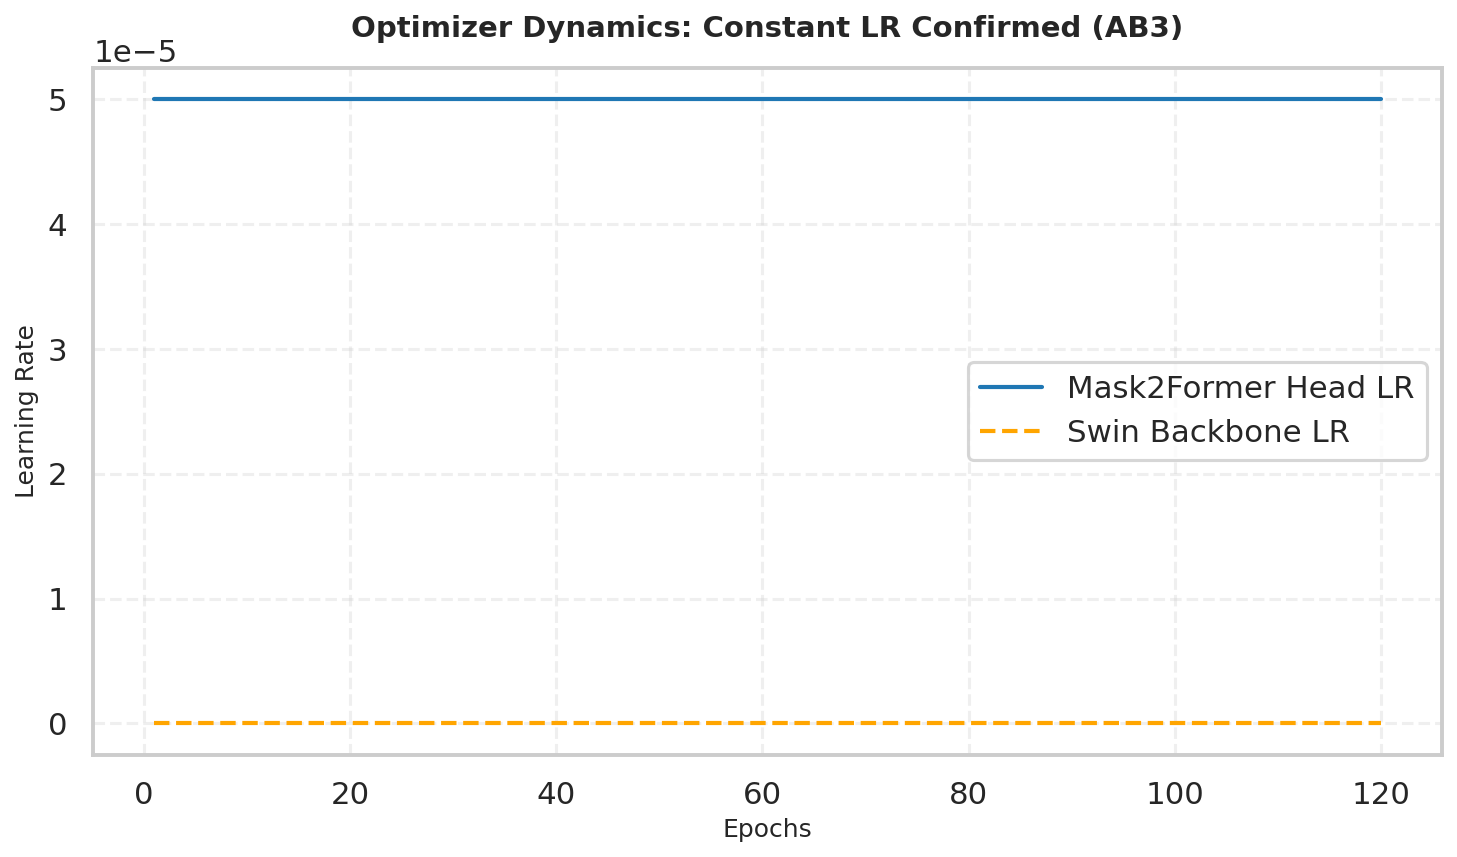

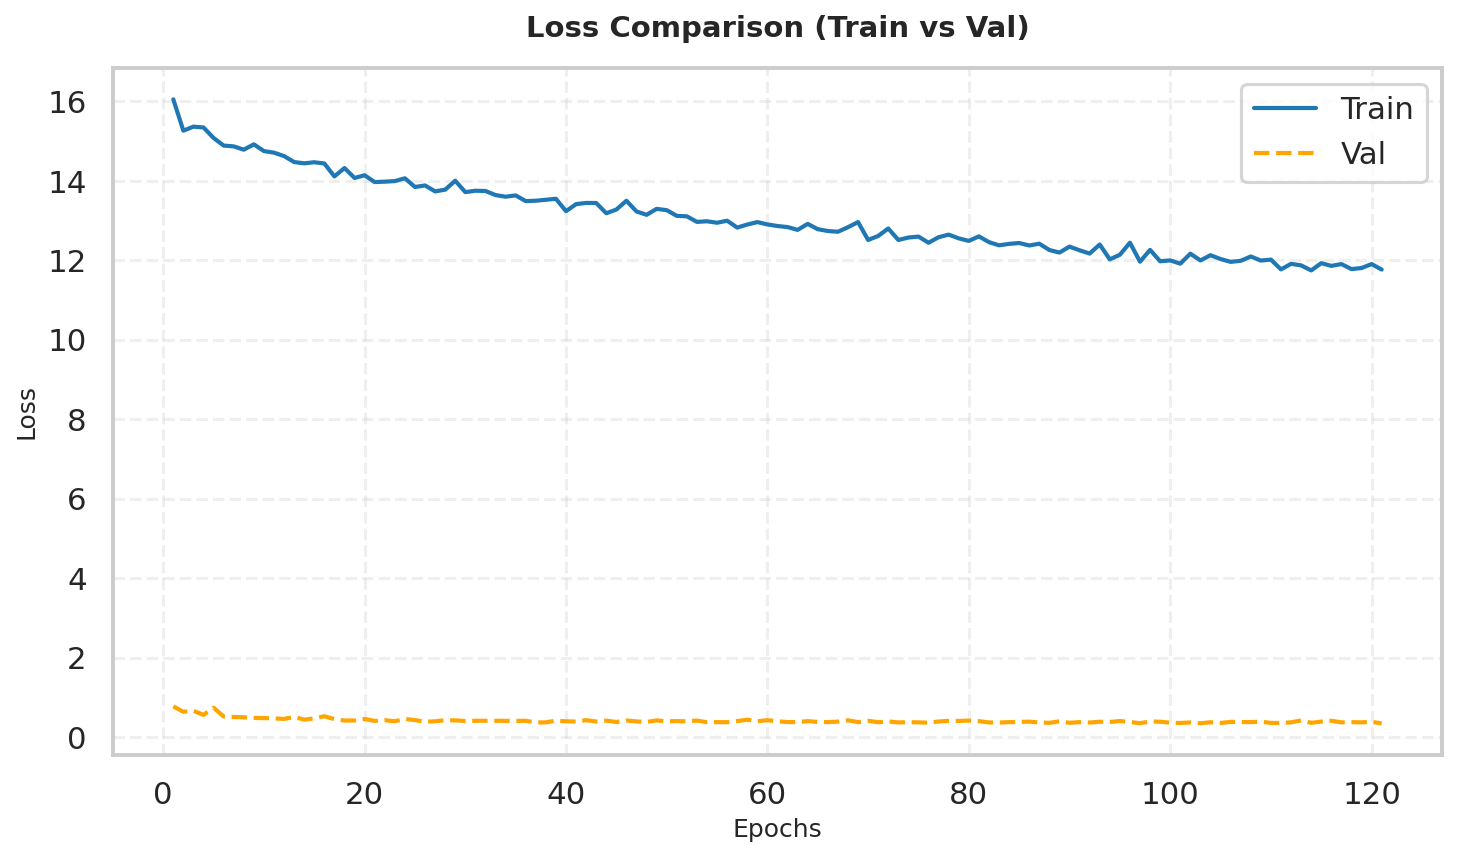

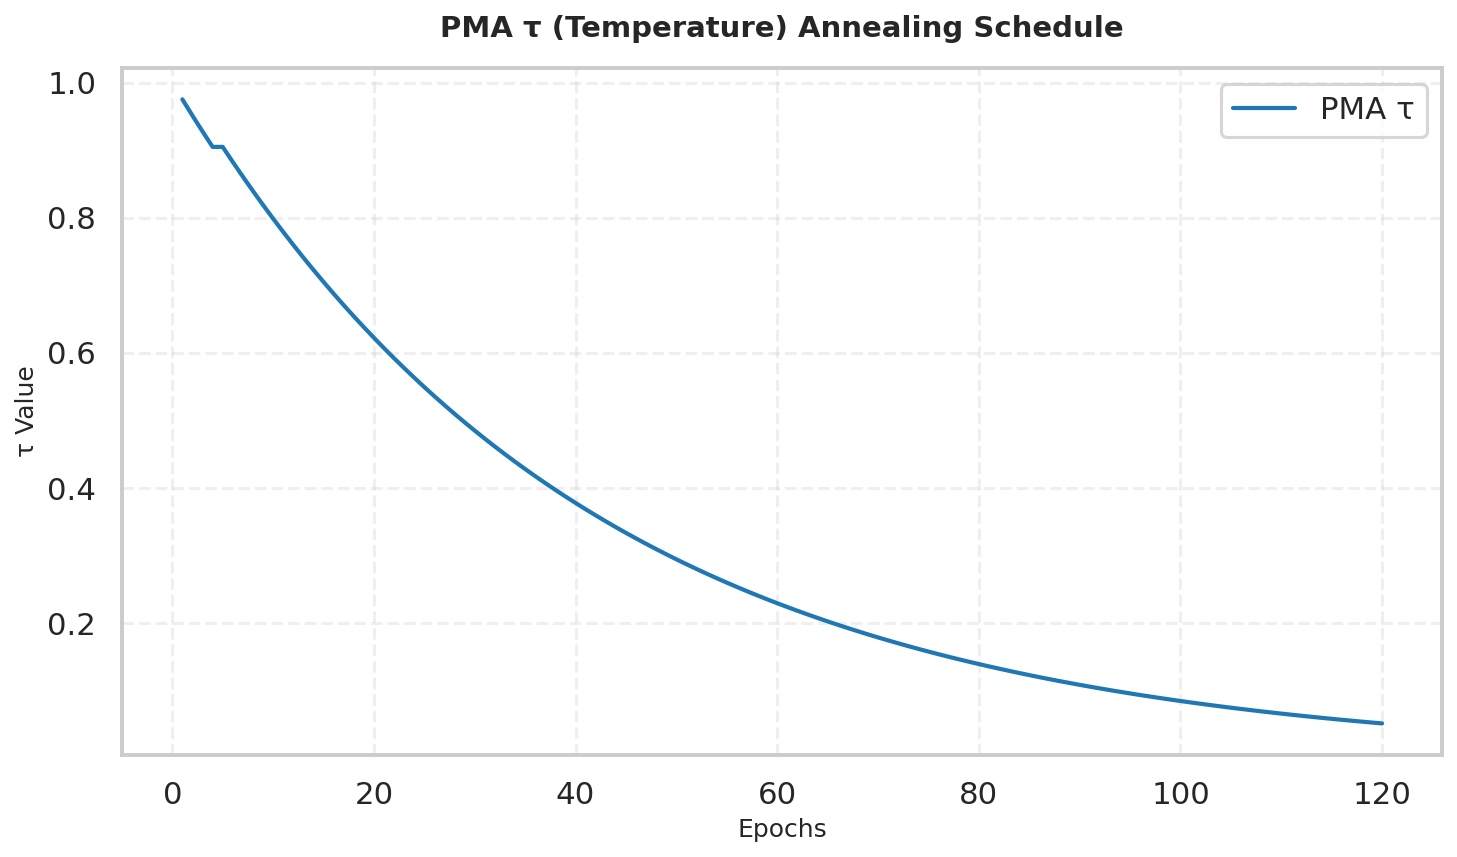

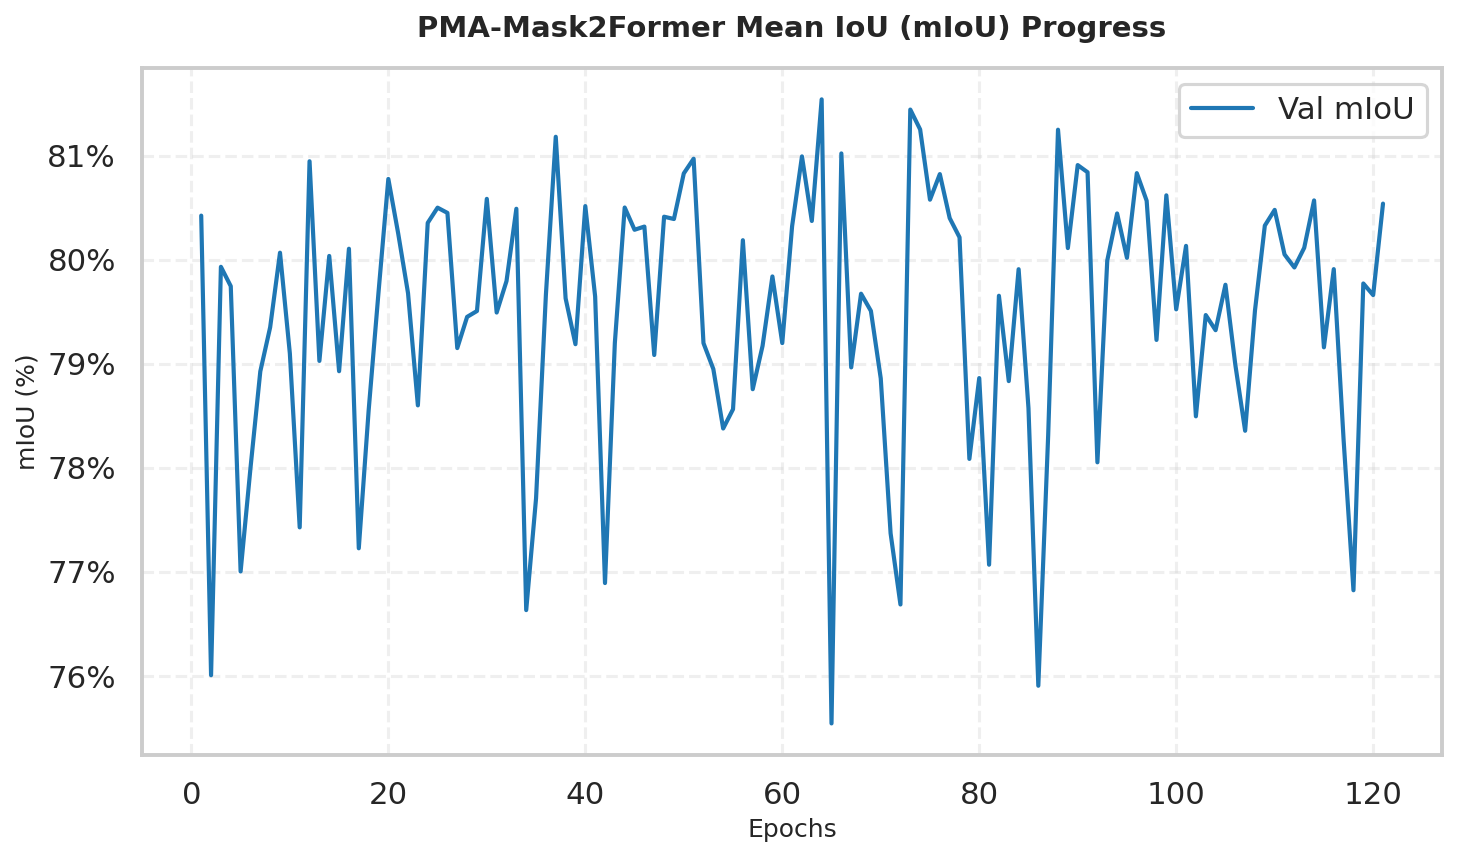

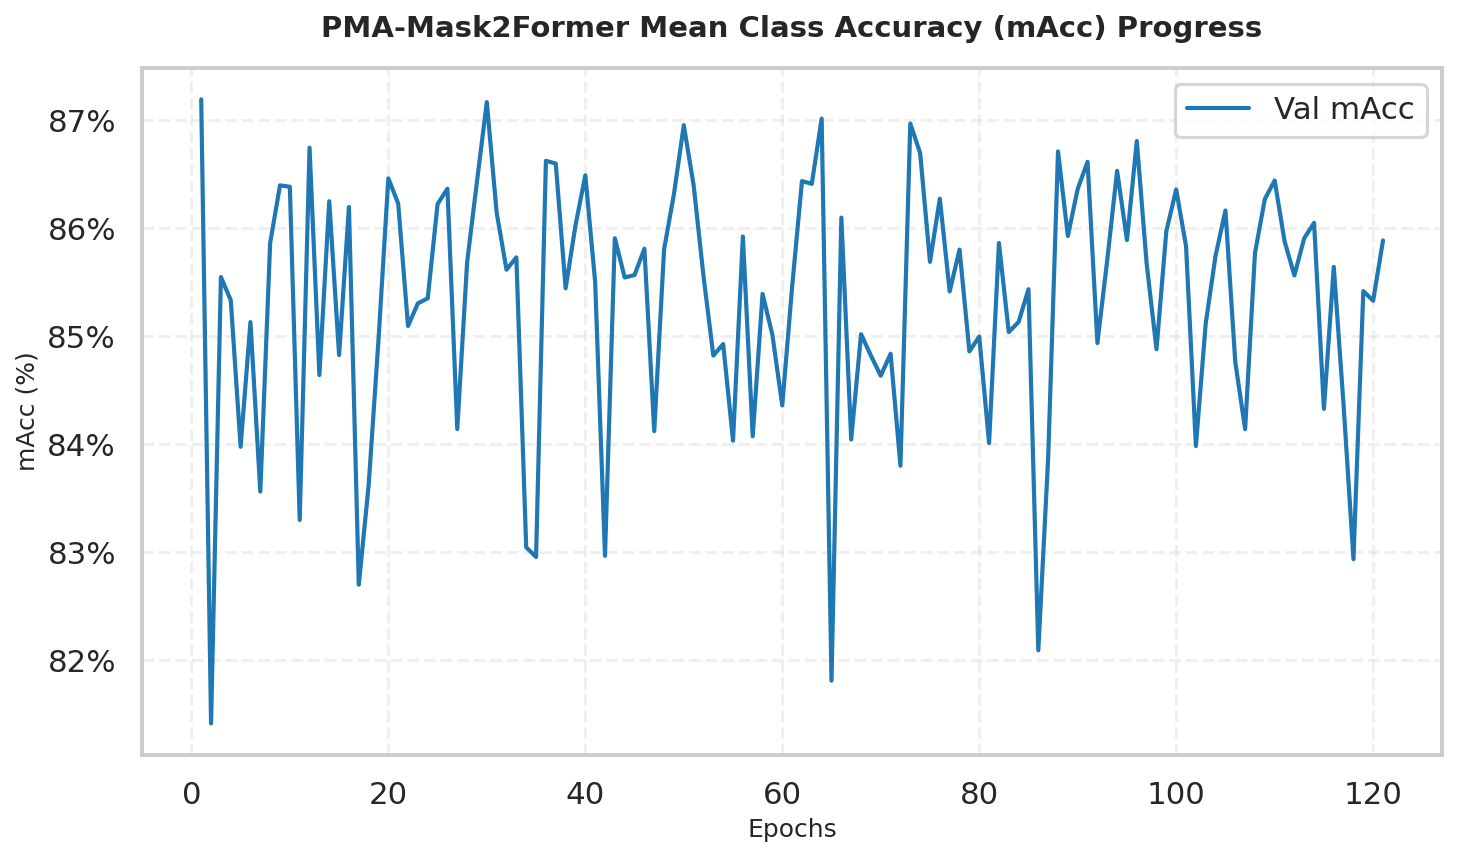

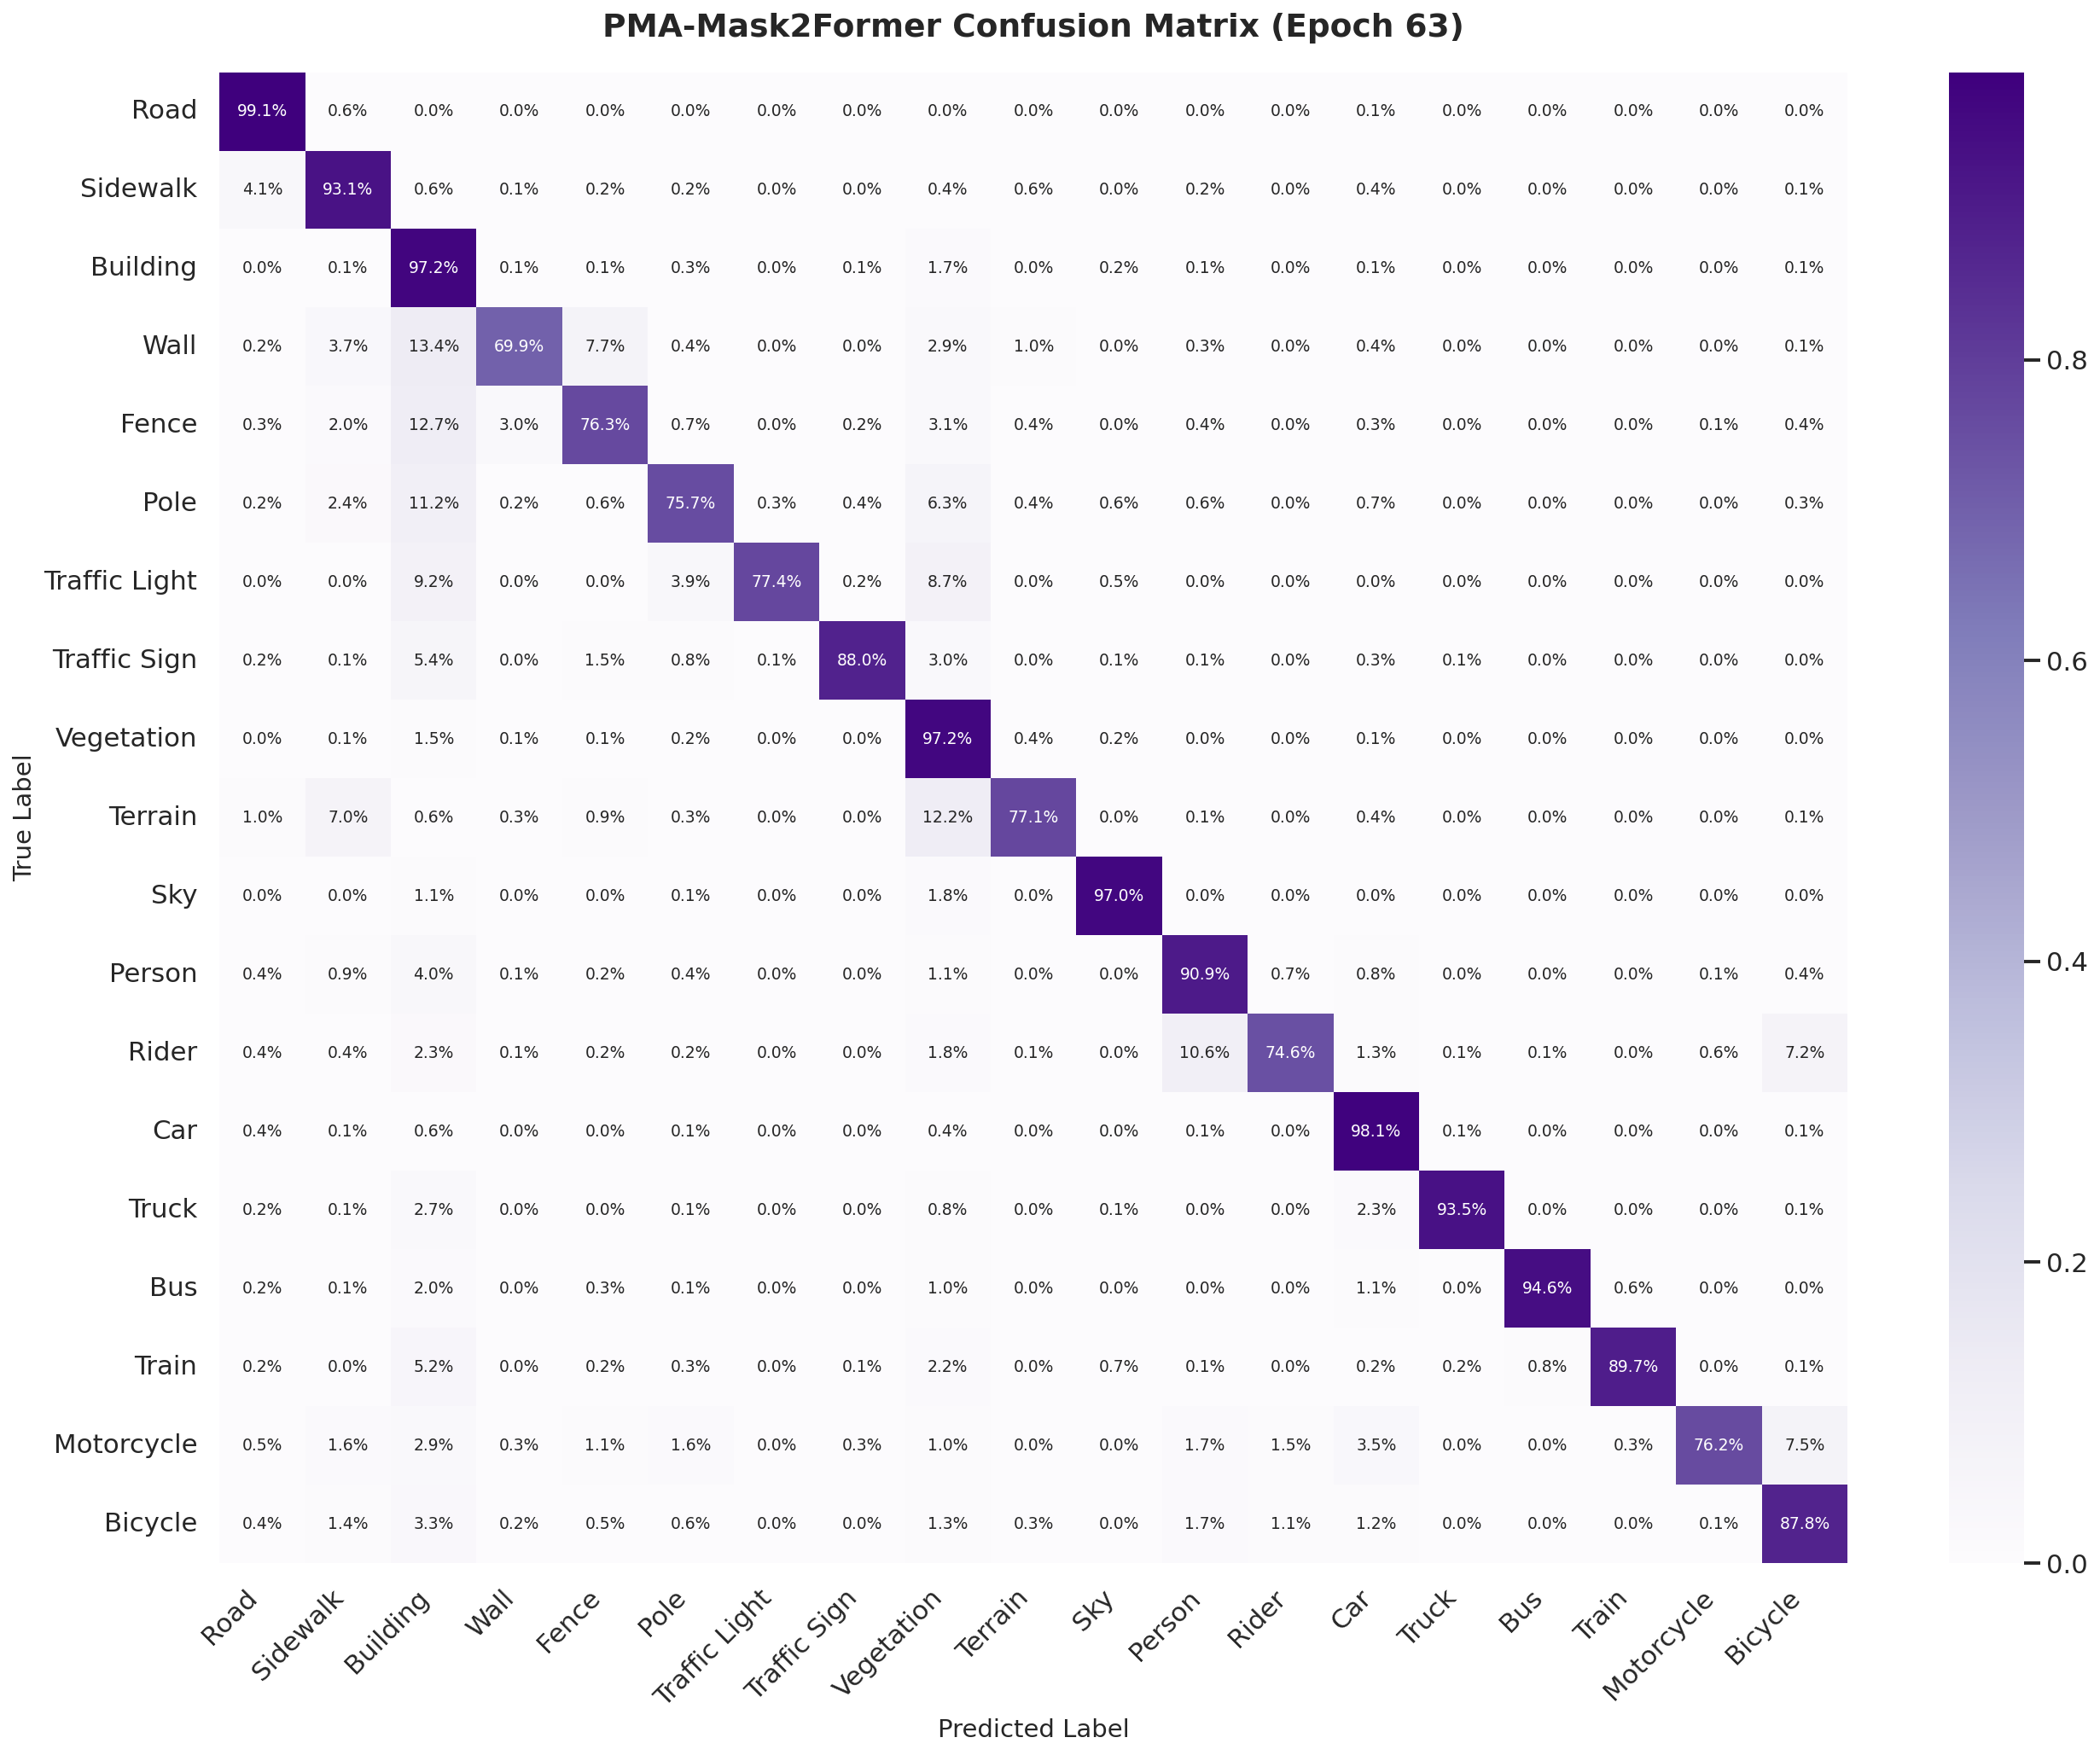


------------------------------------------------------------
Architecture: PMA-Mask2Former
Optimization: SINGLE CONSTANT LEARNING RATE (AB3)
Total Parameters:      68,725,406  (68.73 M)
Trainable Parameters:  68,725,406  (68.73 M)
------------------------------------------------------------
SUCCESS: All artifacts and graphs routed to:
/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export

FINAL RESULTS (AB3 - Constant LR)
Best Validation mIoU:           81.54% (Epoch 63)
Final Epoch Pixel Acc (aAcc):   96.55%
Final Epoch Mean IoU (mIoU):    80.54%
Final Epoch Mean Class Acc:     85.89%
Total Training Time:            2 days, 4:42:23
------------------------------------------------------------
CLASS NAME           | IoU (%)    | Accuracy (%)
------------------------------------------------------------
Road                 | 98.38      | 99.13     
Sidewalk             | 86.33      | 93.06     
Building             | 93.36      | 97.21     
Wall                 |

/home/ubuntu/miniconda3/envs/foggy/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...


Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping constant folding for op Split with multiple outputs.
Skipping

[torch.onnx] Optimize the ONNX graph... ✅
[*] SUCCESS: ONNX Model successfully exported to: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export/PMA_Mask2Former_AB3.onnx


In [10]:
# ============================================================
# STEP 6: EXPORT RESULTS, PLOTS, CONFUSION MATRIX, FINAL SUMMARY
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION (SINGLE CONSTANT LR - AB3)
# ============================================================

import os
import json
from pathlib import Path
from datetime import timedelta

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Force Jupyter to display plots inline
%matplotlib inline

# ------------------------------------------------------------
# MANUAL TIME OVERRIDE
# ------------------------------------------------------------
MANUAL_TOTAL_TIME_STR = None  # Let the script calculate it dynamically

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = [
    "history", "model", "CLASS_NAMES", "CLASSES",
    "CHECKPOINT_DIR", "best_record", "DEVICE"
]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
print(f"Final export directory validated: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# RECOVERY METRICS HELPER 
# ------------------------------------------------------------
def compute_metrics_fallback(conf_matrix: np.ndarray):
    tp = np.diag(conf_matrix)
    fp = conf_matrix.sum(axis=0) - tp
    fn = conf_matrix.sum(axis=1) - tp
    total_valid = conf_matrix.sum()
    aAcc = np.sum(tp) / (total_valid + 1e-10)
    iou_per_class = tp / (tp + fp + fn + 1e-10)
    mIoU = np.nanmean(iou_per_class)
    class_total = tp + fn
    acc_per_class = tp / (class_total + 1e-10)
    mAcc = np.nanmean(acc_per_class)
    return {"mIoU": float(mIoU), "aAcc": float(aAcc), "mAcc": float(mAcc), "iou_per_class": iou_per_class, "acc_per_class": acc_per_class}

BEST_METRICS = globals().get("BEST_METRICS", None)
BEST_CONF_MATRIX = globals().get("BEST_CONF_MATRIX", None)

if BEST_CONF_MATRIX is None and "val_conf_matrix" in globals():
    print("[*] Notice: Live memory of best matrix lost during resume. Using Final Epoch's matrix for class-wise data.")
    BEST_CONF_MATRIX = globals().get("val_conf_matrix")
    BEST_METRICS = compute_metrics_fallback(BEST_CONF_MATRIX)

# ------------------------------------------------------------
# BUILD MAIN DATAFRAME (With Legacy Key Fallbacks)
# ------------------------------------------------------------
num_epochs = len(history["epoch"])

def get_hist_col(key, fallback_key=None):
    col = history.get(key, [])
    if len(col) == num_epochs: return col
    if fallback_key and len(history.get(fallback_key, [])) == num_epochs: return history[fallback_key]
    if len(col) > 0:
        return col + [np.nan] * (num_epochs - len(col)) if len(col) < num_epochs else col[:num_epochs]
    return [np.nan] * num_epochs

df = pd.DataFrame({
    "Epoch": get_hist_col("epoch"),
    "Phase": get_hist_col("phase"),
    "Train_Total_Loss": get_hist_col("train_total_loss", fallback_key="train_loss"),
    "Train_Native_Loss": get_hist_col("train_native_loss"),
    "Train_CE_Loss": get_hist_col("train_ce_loss"),
    "Train_Boundary_Loss": get_hist_col("train_boundary_loss"),
    "PMA_Tau": get_hist_col("pma_tau", fallback_key="apma_tau"),  
    "Train_aAcc": get_hist_col("train_aacc"),
    "Train_mIoU": get_hist_col("train_miou"),
    "Val_Total_Loss": get_hist_col("val_total_loss", fallback_key="val_ce_loss"),
    "Val_CE_Loss": get_hist_col("val_ce_loss"),
    "Val_mIoU": get_hist_col("val_miou"),
    "Val_mAcc": get_hist_col("val_macc"),
    "Val_aAcc": get_hist_col("val_aacc"),
    "LR_Backbone": get_hist_col("backbone_lr"),
    "LR_Head": get_hist_col("head_lr"),
    "Epoch_Time_sec": get_hist_col("epoch_time_sec"),
})

if MANUAL_TOTAL_TIME_STR is not None:
    total_time_str = MANUAL_TOTAL_TIME_STR
else:
    total_training_time_sec = float(df["Epoch_Time_sec"].sum()) if not df["Epoch_Time_sec"].isna().all() else 0.0
    total_time_str = str(timedelta(seconds=int(total_training_time_sec)))

df["Total_Training_Session_Time"] = total_time_str

# ------------------------------------------------------------
# PREPARE CLASS-WISE DATA
# ------------------------------------------------------------
class_wise_data = []
if BEST_METRICS is not None:
    for i, name in enumerate(CLASS_NAMES):
        class_wise_data.append({
            "Class Name": name,
            "IoU (%)": BEST_METRICS["iou_per_class"][i] * 100,
            "Accuracy (%)": BEST_METRICS["acc_per_class"][i] * 100
        })

# ------------------------------------------------------------
# EXPORT FINAL RESULTS CSV & EXCEL
# ------------------------------------------------------------
def safe_pct(val):
    if pd.isna(val) or np.isnan(val): return 0.0
    return val if val > 1.0 else val * 100.0

final_v_acc = safe_pct(df["Val_aAcc"].iloc[-1])
final_mIoU = safe_pct(df["Val_mIoU"].iloc[-1])
final_mAcc = safe_pct(df["Val_mAcc"].iloc[-1])

if "val_miou" in history and len(history["val_miou"]) > 0:
    best_miou_raw = max(history["val_miou"])
    best_idx = history["val_miou"].index(best_miou_raw)
    best_epoch = history["epoch"][best_idx]
    best_miou = safe_pct(best_miou_raw)
else:
    best_epoch = best_record.get("best_epoch", -1)
    best_miou = safe_pct(best_record.get("best_miou", 0.0))

final_global_data = [
    {"Metric": "Best Validation mIoU", "Value": f"{best_miou:.2f}%"},
    {"Metric": "Global Pixel Accuracy (aAcc)", "Value": f"{final_v_acc:.2f}%"},
    {"Metric": "Final Epoch Mean IoU (mIoU)", "Value": f"{final_mIoU:.2f}%"},
    {"Metric": "Final Epoch Mean Class Accuracy (mAcc)", "Value": f"{final_mAcc:.2f}%"},
    {"Metric": "Total Training Time", "Value": total_time_str}
]
pd.DataFrame(final_global_data).to_csv(FINAL_SAVE_DIR / "finalresults_AB3.csv", index=False)

try:
    excel_path = FINAL_SAVE_DIR / "Training_Metrics_Report_AB3.xlsx"
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        df.to_excel(writer, sheet_name='Epoch_Metrics', index=False)
        if class_wise_data:
            pd.DataFrame(class_wise_data).to_excel(writer, sheet_name='Class_Wise_Results', index=False)
except ImportError:
    pass  

# ------------------------------------------------------------
# STANDARD SEPARATE PLOTS 
# ------------------------------------------------------------
sns.set_style("whitegrid")

def save_and_show_plot(filename, title, ylabel, train_data, val_data=None, label1="Train", label2="Val"):
    plt.figure(figsize=(10, 6))
    
    epochs_range = range(1, len(train_data) + 1)
    train_clean = np.array(train_data, dtype=float)
    plt.plot(epochs_range, train_clean, label=label1, lw=2)
    
    if val_data is not None:
        val_clean = np.array(val_data, dtype=float)
        if not np.isnan(val_clean).all():
            plt.plot(epochs_range, val_clean, label=label2, lw=2, color='orange', linestyle='--')
            
    if "(%)" in ylabel:
        plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}%".format(int(x))))

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Epochs", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / f"{filename}.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# Extract data for plotting
train_loss = df["Train_Total_Loss"].tolist()
val_loss = df["Val_CE_Loss"].tolist()
pma_tau = df["PMA_Tau"].tolist()
lr_backbone = df["LR_Backbone"].tolist()
lr_head = df["LR_Head"].tolist()

def ensure_percentage(series):
    if series.isna().all(): return None
    data = series.tolist()
    return [x * 100 if (x is not None and x <= 1.0) else x for x in data]

val_miou = ensure_percentage(df["Val_mIoU"])
val_macc = ensure_percentage(df["Val_mAcc"])

# 1. Constant LR Proof (AB3 Specific)
save_and_show_plot("learning_rate_dynamics_AB3", "Optimizer Dynamics: Constant LR Confirmed (AB3)", "Learning Rate", lr_head, val_data=lr_backbone, label1="Mask2Former Head LR", label2="Swin Backbone LR")

# 2. Loss Plots 
save_and_show_plot("loss_comparison_AB3", "Loss Comparison (Train vs Val)", "Loss", train_loss, val_loss)

# 3. PMA Temperature Plot
if not df["PMA_Tau"].isna().all():
    save_and_show_plot("pma_tau_decay_AB3", "PMA \u03c4 (Temperature) Annealing Schedule", "\u03c4 Value", pma_tau, label1="PMA \u03c4")

# 4. Presentation Plots (Warmup filtering removed for AB3)
if val_miou is not None:
    save_and_show_plot("miou_progress_AB3", "PMA-Mask2Former Mean IoU (mIoU) Progress", "mIoU (%)", val_miou, label1="Val mIoU")
if val_macc is not None:
    save_and_show_plot("macc_progress_AB3", "PMA-Mask2Former Mean Class Accuracy (mAcc) Progress", "mAcc (%)", val_macc, label1="Val mAcc")

# ------------------------------------------------------------
# PERCENTAGE-BASED CONFUSION MATRIX
# ------------------------------------------------------------
if BEST_CONF_MATRIX is not None:
    plt.figure(figsize=(18, 14)) 
    cm_normalized = BEST_CONF_MATRIX.astype('float') / (BEST_CONF_MATRIX.sum(axis=1)[:, np.newaxis] + 1e-10)
    
    sns.heatmap(
        cm_normalized, annot=True, fmt='.1%', cmap='Purples', 
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
        annot_kws={"size": 9}
    ) 
    
    plt.title(f"PMA-Mask2Former Confusion Matrix (Epoch {best_epoch})", fontsize=18, fontweight='bold', pad=20)
    plt.ylabel('True Label', fontsize=14)
    plt.xlabel('Predicted Label', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FINAL_SAVE_DIR / "confusion_matrix_percentages_AB3.png", dpi=600, bbox_inches='tight')
    plt.show() 
    plt.close()

# ------------------------------------------------------------
# PARAMETER COUNT & FINAL PRINT SUMMARY (Moved BEFORE ONNX)
# ------------------------------------------------------------
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n" + "-"*60)
print(f"Architecture: PMA-Mask2Former")
print(f"Optimization: SINGLE CONSTANT LEARNING RATE (AB3)")
print(f"Total Parameters:      {total_params:,}  ({total_params/1e6:.2f} M)")
print(f"Trainable Parameters:  {trainable_params:,}  ({trainable_params/1e6:.2f} M)")
print(f"-"*60)
print(f"SUCCESS: All artifacts and graphs routed to:\n{FINAL_SAVE_DIR.resolve()}")
print("\n" + "="*60)
print(f"FINAL RESULTS (AB3 - Constant LR)")
print("="*60)
print(f"Best Validation mIoU:           {best_miou:.2f}% (Epoch {best_epoch})")
print(f"Final Epoch Pixel Acc (aAcc):   {final_v_acc:.2f}%")
print(f"Final Epoch Mean IoU (mIoU):    {final_mIoU:.2f}%")
print(f"Final Epoch Mean Class Acc:     {final_mAcc:.2f}%")
print(f"Total Training Time:            {total_time_str}")
print("-" * 60)
print(f"{'CLASS NAME':<20} | {'IoU (%)':<10} | {'Accuracy (%)':<10}")
print("-" * 60)

if class_wise_data:
    for item in class_wise_data:
        print(f"{item['Class Name']:<20} | {item['IoU (%)']:<10.2f} | {item['Accuracy (%)']:<10.2f}")
else:
    print("[!] No class-wise data available in memory to print.")

# ------------------------------------------------------------
# ONNX MODEL EXPORT (Opset 18)
# ------------------------------------------------------------
print("\n--- Exporting AB3 PMA-Mask2Former to ONNX (Opset 18) ---")
try:
    model.eval()
    dummy_input = torch.randn(1, 3, 512, 1024, device=DEVICE)
    onnx_path = FINAL_SAVE_DIR / "PMA_Mask2Former_AB3.onnx"
    
    with torch.no_grad():
        torch.onnx.export(
            model, dummy_input, str(onnx_path),
            export_params=True, opset_version=18,
            do_constant_folding=True, input_names=['input_image'], output_names=['mask_predictions']
        )
    print(f"[*] SUCCESS: ONNX Model successfully exported to: {onnx_path.resolve()}")
except Exception as e:
    print(f"[!] Info: ONNX export skipped due to internal PyTorch C++ limits: {e}")

Presentation graph will be exported to: /home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export
Graph saved successfully to:
/home/ubuntu/Pictures/swinsmall_Mask2Former_PMA_CS_constLR_AB3/Results_Export/presentation_metrics_progress_AB3.png


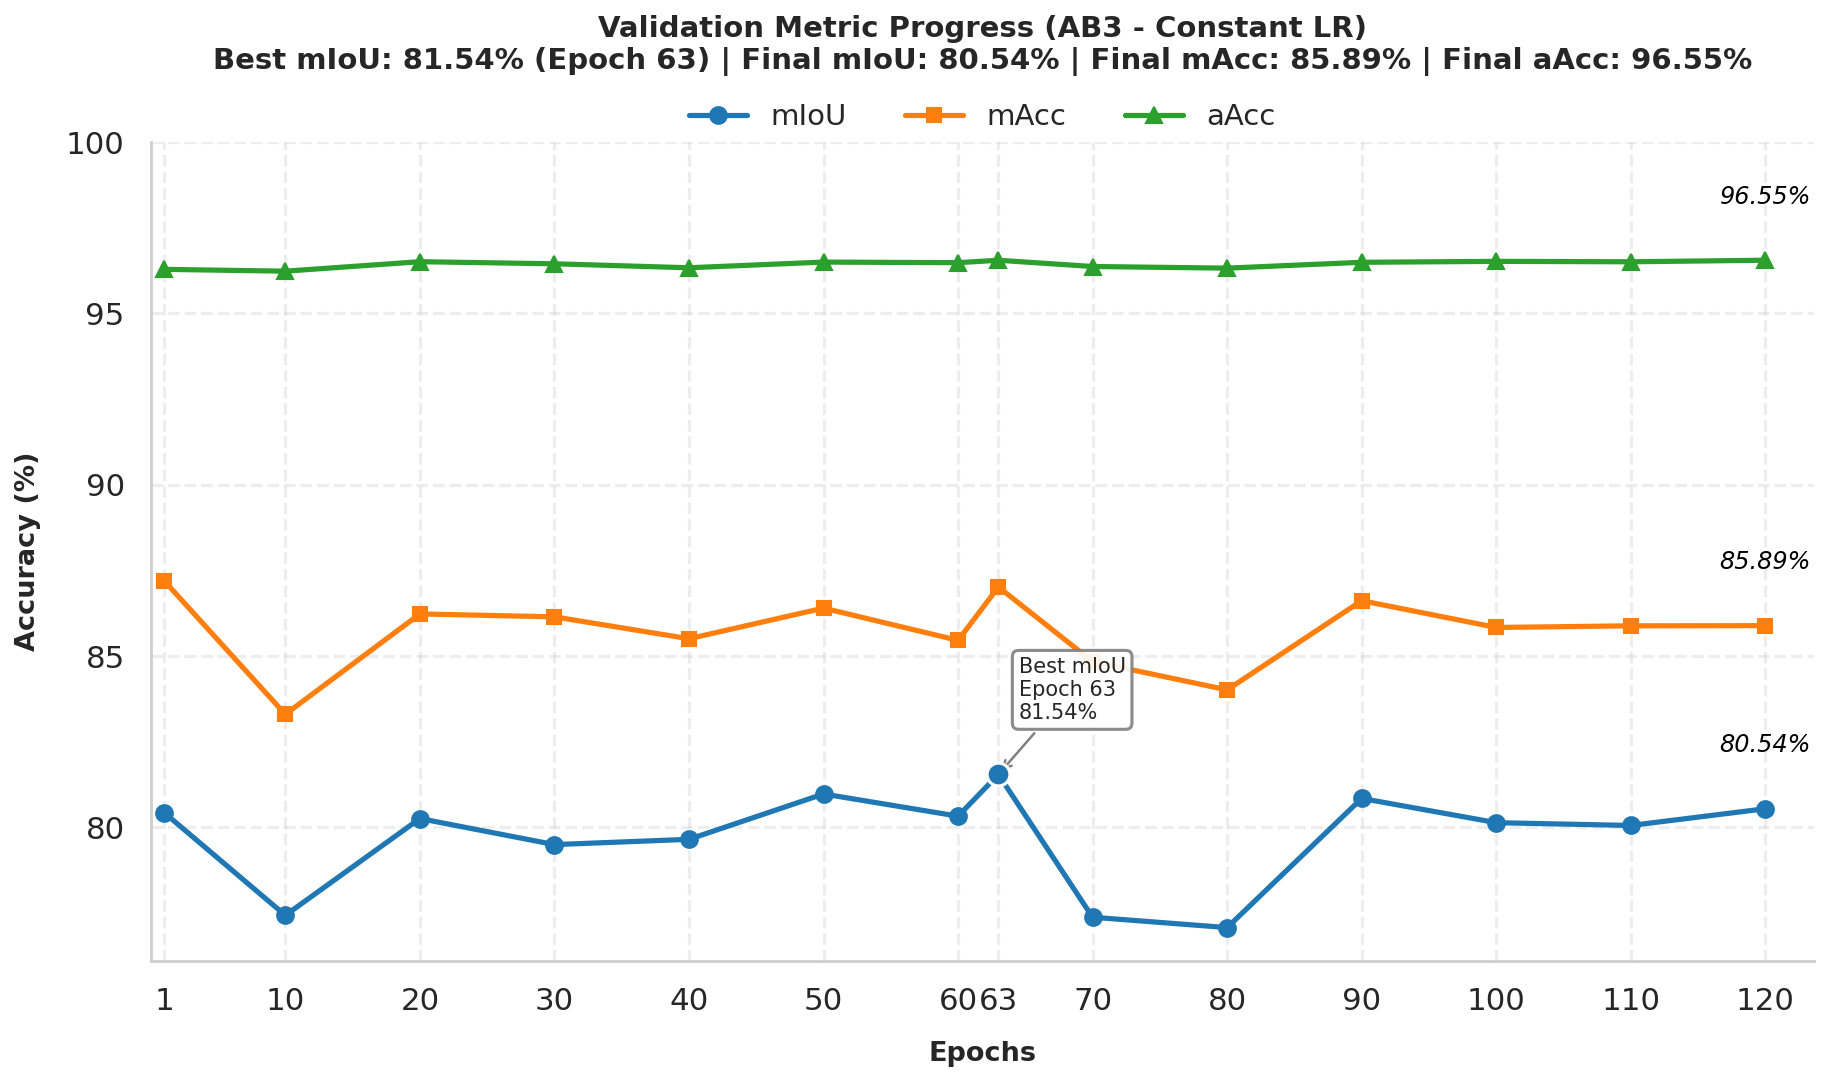

In [11]:
# ============================================================
# STEP 7: PRESENTATION-READY MULTI-METRIC PROGRESS GRAPH
# Target Architecture: Swin-Small + Mask2Former + PMA
# Target Dataset: Cityscapes
# Optimization Mode: ABLATION (SINGLE CONSTANT LR - AB3)
# Optimized for: Global Path Inheritance, Specific Epoch Intervals,
# and Strict Percentage Scaling for Publication
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# SAFETY CHECKS & PATH INHERITANCE
# ------------------------------------------------------------
required_globals = ["history"]
missing = [k for k in required_globals if k not in globals()]
if missing:
    raise NameError(f"Missing required variables from previous steps: {missing}")

if "val_miou" not in history or len(history["val_miou"]) == 0:
    raise ValueError("history['val_miou'] is empty. Run training (Step 5) before Step 7.")

# Inherit the centralized export directory securely from Step 1
FINAL_SAVE_DIR = globals().get("FINAL_SAVE_DIR", Path("./Results_Export"))
print(f"Presentation graph will be exported to: {FINAL_SAVE_DIR.resolve()}")

# ------------------------------------------------------------
# PREPARE EPOCHS & DATA
# ------------------------------------------------------------
all_epochs = history["epoch"]

# Safe percentage converter (prevents 80% turning into 8000% if already scaled in Step 5)
def safe_pct(val):
    return val * 100.0 if val <= 1.0 else float(val)

# Bulletproof Best Epoch Extraction
best_miou_raw = max(history["val_miou"])
best_idx = history["val_miou"].index(best_miou_raw)
best_miou = safe_pct(best_miou_raw)
best_miou_epoch = all_epochs[best_idx]

# Filter epochs to reduce visual clutter: Epoch 1, every 10th epoch, best epoch, final epoch
filtered_epochs_set = set([e for e in all_epochs if e == 1 or e % 10 == 0] + [all_epochs[-1], best_miou_epoch])
filtered_epochs = sorted(list(filtered_epochs_set))

indices = [all_epochs.index(e) for e in filtered_epochs]

# Extract and convert to percentages for cleaner presentation
miou_scores = [safe_pct(history["val_miou"][i]) for i in indices]
macc_scores = [safe_pct(history["val_macc"][i]) for i in indices]
aacc_scores = [safe_pct(history["val_aacc"][i]) for i in indices]

final_miou = safe_pct(history["val_miou"][-1])
final_macc = safe_pct(history["val_macc"][-1])
final_aacc = safe_pct(history["val_aacc"][-1])
final_x = all_epochs[-1]

# ------------------------------------------------------------
# PLOT SETUP 
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.5, 7.5)) 

color_miou = '#1f77b4'  # Blue
color_macc = '#ff7f0e'  # Orange
color_aacc = '#2ca02c'  # Green

ax.plot(filtered_epochs, miou_scores, marker='o', linewidth=2.5, markersize=8, label='mIoU', color=color_miou)
ax.plot(filtered_epochs, macc_scores, marker='s', linewidth=2.5, markersize=7, label='mAcc', color=color_macc)
ax.plot(filtered_epochs, aacc_scores, marker='^', linewidth=2.5, markersize=8, label='aAcc', color=color_aacc)

# ------------------------------------------------------------
# AXIS LABELS
# ------------------------------------------------------------
ax.set_xlabel('Epochs', fontsize=13, fontweight='bold', labelpad=12)
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold', labelpad=12)
ax.set_xticks(filtered_epochs)

# ------------------------------------------------------------
# BEST mIoU ANNOTATION 
# ------------------------------------------------------------
ax.scatter(best_miou_epoch, best_miou, s=120, zorder=5, color=color_miou, edgecolors='white', linewidth=1.5)

if best_miou_epoch <= (max(filtered_epochs) * 0.6):
    best_text_x = best_miou_epoch + 1.5
    best_ha = "left"
else:
    best_text_x = best_miou_epoch - 1.5
    best_ha = "right"

ax.annotate(
    f'Best mIoU\nEpoch {best_miou_epoch}\n{best_miou:.2f}%',
    xy=(best_miou_epoch, best_miou),
    xytext=(best_text_x, best_miou + 1.5),
    fontsize=10, ha=best_ha, va='bottom',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
    arrowprops=dict(arrowstyle='->', color='gray', lw=1.2)
)

# ------------------------------------------------------------
# END-OF-LINE FINAL VALUE ANNOTATIONS (Floating above markers)
# ------------------------------------------------------------
# Placed slightly above the final points to match the target aesthetic
offset_y = 1.5

ax.text(final_x, final_miou + offset_y, f'{final_miou:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_macc + offset_y, f'{final_macc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')
ax.text(final_x, final_aacc + offset_y, f'{final_aacc:.2f}%', va='bottom', ha='center', fontsize=11.5, fontstyle='italic', color='black')

ax.set_xlim(left=0, right=max(all_epochs) + (max(all_epochs) * 0.03))
ax.set_ylim(top=100) 

# ------------------------------------------------------------
# STYLING & LEGEND
# ------------------------------------------------------------
# Center the legend horizontally above the plot area
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, frameon=False, fontsize=14)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(1.3)
ax.spines['left'].set_linewidth(1.3)

ax.grid(True, linestyle='--', alpha=0.35)

title_main = "Validation Metric Progress (AB3 - Constant LR)"
title_sub = f"Best mIoU: {best_miou:.2f}% (Epoch {best_miou_epoch}) | Final mIoU: {final_miou:.2f}% | Final mAcc: {final_macc:.2f}% | Final aAcc: {final_aacc:.2f}%"

# Pushed the title up slightly to make room for the new legend position
ax.set_title(
    title_main + "\n" + title_sub,
    fontsize=14, fontweight='bold', pad=35
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------
# Directly save the single, unified presentation-ready graph
combined_graph_path = FINAL_SAVE_DIR / "presentation_metrics_progress_AB3.png"
plt.savefig(combined_graph_path, dpi=600, bbox_inches='tight')
print(f"Graph saved successfully to:\n{combined_graph_path.resolve()}")

plt.show()
plt.close()